# Minitrabalho DAA — Análise de Redes Ficcionais

## Grupo
- Diogo Teixeira       Nº129840
- Rodrigo Leal         Nº129847
- Rúben Lopes Fonseca  Nº129837

## Objetivo

Neste trabalho implementámos uma API de análise de redes baseada em grafos não orientados, permitindo calcular métricas estruturais e métricas de centralidade em universos ficcionais como *Game of Thrones* e *Marvel*.

Foram implementados algoritmos para:
- BFS
- Componentes conexas
- Distribuição de graus
- Diâmetro
- Degree Centrality
- Closeness Centrality
- Eigenvector Centrality
- Betweenness Centrality (Brandes)

Além disso, analisámos empiricamente a escalabilidade temporal dos algoritmos.

## Imports usados no trabalho

In [1]:
from collections import deque
import csv
import time
import statistics
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import numpy as np

## 0. Representação de grafos

De modo a representar-mos grafos em python, decidimos usar as classes Vertex, Edge e Graph

### Classe Vertex

Segue-se a implementação da classe Vertex abaixo

In [2]:
# Class Vertice
class Vertex:
    ''' Estrutura de Vértice para um grafo: encapsula um elemento (vertex_id) 
        que é o identificador deste nó.
        
        O elemento (vertex_id) deve ser hashable:  
        - Um objeto hashable é aquele que pode ser utilizado como uma chave num dicionário Python.
        - Isto inclui strings, números, tuplas, etc.
    '''
    
    def __init__(self, vertex_id):
        '''O vértice será inserido no Grafo usando o método insert_vertex(x) que cria um Vertex'''
        self._vertex_id = vertex_id   # Id do vértice (elemento a inserir no grafo)
        
    def __hash__(self):
        '''O valor do elemento é usado como hash para o vértice (o elemento deve ser hashable)'''
        return hash(self._vertex_id)  # devolve o hash do elemento

    def __str__(self):
        '''Devolve a representação do objeto vértice em string.'''
        return'v{0}'.format(self._vertex_id)

    def __eq__(self, vertex):
        return self._vertex_id == vertex._vertex_id # Deve-se garantir que: se hash(vertex)==hash(self), entao vertex==self

    def __lt__(self, vertex):
        return self._vertex_id < vertex._vertex_id
    
    def __le__(self, vertex):
        return self._vertex_id <= vertex._vertex_id
    
    def __gt__(self, vertex):
        return self._vertex_id > vertex._vertex_id
    
    def __ge__(self, vertex):
        return self._vertex_id >= vertex._vertex_id
    
    def vertex_id(self):
        ''' Devolve o elemento guardado neste vértice.'''
        return self._vertex_id

### Classe Edge

Segue-se a implementação da classe Edge abaixo

In [3]:
# Class Edge
class Edge:
    ''' Estrutura de Aresta para um Grafo: (origem, destino) e peso '''

    def __init__(self, vertex_1, vertex_2, weight):
        self._vertex_1 = vertex_1
        self._vertex_2 = vertex_2
        self._weight = weight

    def __hash__(self):
        # Função que mapeia a aresta a uma posição no dicionário (hash map)
        return hash( (self._vertex_1, self._vertex_2) )

    def __str__(self):
        ''' Devolve a representação do objeto aresta em string: (origem, destino)w=peso '''
        return'e({0},{1})w={2}'.format(self._vertex_1, self._vertex_2, self._weight)

    def __eq__(self, other):
        # define igualdade de duas arestas (deve ser consistente com a função hash)
        return self._vertex_1 == other._vertex_1 and self._vertex_2 == other._vertex_2

    def endpoints(self):
        ''' Devolve a tupla (vertex_1, vertex_2) os vértices adjacentes vertex_1 e vertex_2.'''
        return (self._vertex_1, self._vertex_2)

    def cost(self):
        ''' Devolve o peso associado a este arco.'''
        return self._weight
    
    def opposite(self, vertex):
        ''' Indica o vértice oposto ao vertex nesta aresta 
            (apenas se vertex fizer parte da aresta).'''
        if vertex == self._vertex_1:
            return self._vertex_2
        elif vertex == self._vertex_2:
            return self._vertex_1
        else:
            return None

### Classe Graph

Segue-se a implementação da classe Graph abaixo (com adição de um método com a finalidade de carregar um grafo a partir de um ficheiro .csv)

In [4]:
class Graph:
    '''
    Representação de um grafo usando dicionários encadeados (nested dictionaries).
    
    Atributos:
    ----------
    adjancencies: Dicionário externo que associa um vértice (Vertex) a um  
                  mapa de adjacências (dicionario interno)
                  Em vez de utilizar uma estrutura com um array (como nos slides),
                  utiliza uma estrutura do tipo "dicionário de dicionários":
                  < vertex , < neighbor_vertex , edge > >
                  
    vertices: Dicionário auxiliar que associa o id dos vértices do grafo
              a um objeto Vertex (tabela de símbolos):
              < vertex_id , vertex >
              
    n: Número de vértices no Grafo
    m: Número de arestas no Grafo
    
    ----------
'''
    def __init__(self):
        '''Construtor: Cria um grafo vazio (dicionário de _adjancencies).'''
        
        self._adjancencies = {}  # dicionário que associa o par chave-valor: <Vertex v, Mapa de adjacências de v> 
        self._vertices = {}      # dicionário que associa o par: <id do vértice, objeto Vertex correspondente> 
        self._n = 0              # número de vértices do grafo
        self._m = 0              # número de arestas do grafo
    
    def __str__(self):
        '''Devolve a representação do grafo em string (toString)'''
        if self._n == 0:
            ret = "DAA-Graph: <empty>\n"
        else:
            ret = "DAA-Graph:\n"
            for vertex in self._adjancencies.keys():
                #ret += "vertex-"
                ret += str(vertex) + ": "
                for edge in self.incident_edges(vertex.vertex_id()):
                    ret += str(edge) + "; "
                ret += "\n"
        return ret
    
    @classmethod
    def from_csv(cls, path):
        graph = cls()

        with open(path, "r", encoding="utf-8") as file:

            reader = csv.DictReader(file)

            for row in reader:

                source = row["Source"]
                target = row["Target"]
                weight = int(row["Weight"])

                if not graph.has_vertex(source):
                    graph.insert_vertex(source)

                if not graph.has_vertex(target):
                    graph.insert_vertex(target)

                graph.insert_edge(source, target, weight)

        return graph

    def is_directed(self):
        '''A classe Graph representa um grafo não orientado.'''
        return False
    
    def order(self):
        '''Ordem de um grafo: a quantidade de vértices no Grafo.'''
        return self._n
    
    def size(self):
        '''Dimensão de um grafo: a quantidade total de arestas do Grafo.'''
        return self._m 
    
    def has_vertex(self, vertex_id):
        '''Verifica se o vértice de id vertex_id está no grafo.'''
        return vertex_id in self._vertices
    
    def has_edge(self, u_id, v_id):
        '''Verifica se a aresta (u_id, v_id) existe no grafo.'''
        if not self.has_vertex(u_id) or not self.has_vertex(v_id):
            return False
        else:
            vertex_u = self._vertices[u_id]
            vertex_v = self._vertices[v_id]
            return vertex_v in self._adjancencies[vertex_u]
        
    def insert_vertex(self, vertex_id):
        '''Insere um novo vértice com o id vertex_id.'''
        if not self.has_vertex(vertex_id):
            vertex = Vertex(vertex_id)          # instancia um objeto do tipo Vertex
            self._vertices[vertex_id] = vertex  # insere o novo vértice no dicionário de vertices
            self._adjancencies[vertex] = {}     # inicializa o mapa de adjacências deste vértice a vazio
            self._n +=1                         # mais um vértice no grafo

    def insert_edge(self, u_id, v_id, weight=0):
        ''' Cria e insere uma nova aresta entre u_id e v_id com peso weight.
            Se a aresta já existe no grafo, atualiza-se o seu peso.
            Também insere os vértices u_id e v_id, caso não existam.'''
        if not self.has_vertex(u_id):
            self.insert_vertex(u_id) # insere novo vertex e atualiza n
        if not self.has_vertex(v_id):
            self.insert_vertex(v_id) # insere novo vertex e atualiza n      
        if not self.has_edge(u_id, v_id):
            self._m +=1           # atualiza m apenas se a aresta ainda não existir no grafo
        #else:
        #    print(f"Existing edge {u_id} and {v_id}. Will only update weight")
        vertex_u = self._vertices[u_id]  # acede ao objeto Vertex associado a u_id
        vertex_v = self._vertices[v_id]  # acede ao objeto Vertex associado a v_id
        e = Edge(vertex_u, vertex_v, weight)    
        self._adjancencies[vertex_u][vertex_v] = e  # coloca v nas adjacências de u
        self._adjancencies[vertex_v][vertex_u] = e  # e u nas adjacências de v (para facilitar a procura de todas as arestas incidentes num vértice)
    
    def degree(self, vertex_id):
        '''Quantidade de arestas incidentes no vértice v.
        '''
        return len(self._adjancencies[self._vertices[vertex_id]])
    
    def get_vertex(self, vertex_id):
        ''' Devolve o objeto Vertex associado ao elemento vertex_id no grafo
        '''
        return None if not self.has_vertex(vertex_id) else self._vertices[vertex_id] 
    
    def get_edge(self, u_id, v_id):
        ''' Devolve o objeto aresta (Edge) que liga u_id a v_id. 
            Devolve None se não forem adjacentes ou se (um d)os vértices não existirem.'''  
        if not self.has_edge(u_id, v_id):
            return None
        else:
            vertex_u = self._vertices[u_id]
            vertex_v = self._vertices[v_id]
            return self._adjancencies[vertex_u][vertex_v]
    
    def vertices(self):
        '''Devolve um iterável sobre todos os vértices do Grafo (tipo Vertex)'''
        return self._vertices.values()

    def edges(self):
        '''Devolve um iterável sobre todas as arestas do Grafo (sem arestas duplicadas).'''
        seen = {}      # evita a repetição de arestas no grafo não orientado
        for adj_map in self._adjancencies.values():
            for edge in adj_map.values():
                if edge not in seen:
                    yield edge
                seen[edge] = True

    def incident_edges(self, vertex_id):
        '''Devolve um iterável (gerador) com todas as arestas de um vértice com id vertex_id.'''
        vertex = self._vertices[vertex_id]
        for edge in self._adjancencies[vertex].values(): # para todas as arestas incidentes em v:
            yield edge

    def has_neighbors(self, vertex_id):
        '''Verifica se o vértice de id vertex_id tem vértices adjacentes (vizinhos).'''
        if not self.has_vertex(vertex_id):
            return False
        return self.degree(vertex_id) > 0
    
    def remove_vertex(self, vertex_id):
        '''Remove o vértice com id vertex_id. Se o vértice não existir, não faz nada.'''
        # Passo 1: remover todas as arestas do vértice dado
        # Passo 2: remover todas as arestas incidentes em vertex_id dos mapas de outros vertices
        # Passo 3: remover o vértice com id vertex_id do grafo
        # Passo 4: decrementa contador de vértices
        if self.has_vertex(vertex_id):
            lst_copied = list(self.incident_edges(vertex_id)) # copia para a lista para evitar erros de concorrência (remove enquanto itera na lista)
            for edge in lst_copied:
                x, y = edge.endpoints()
                self.remove_edge(x.vertex_id(),y.vertex_id())  # (Passos 1 e 2)
            del self._adjancencies[self._vertices[vertex_id]]  # (Passo 3 - remove do dicionário de adjacências)
            del self._vertices[vertex_id]                      # (Passo 3 - remove do dicionário de vértices)
            self._n -=1                                        # (Passo 4 - decrementa contador)
        
    def remove_edge(self, u_id, v_id):
        '''Remove a aresta entre u_id e v_id. Se a aresta não existir, não faz nada.'''
        if  self.has_edge(u_id, v_id):
            vertex_u = self._vertices[u_id]
            vertex_v = self._vertices[v_id]
            del self._adjancencies[vertex_u][vertex_v]
            if vertex_u != vertex_v:  # laços são removidos apenas uma vez
                del self._adjancencies[vertex_v][vertex_u]
            self._m -=1


# 1. API CentralityAnalyzer

Abaixo encontra-se a implementação da classe CentralityAnalyzer que contem várias funções que permitem calcular métricas de centralidade, componentes conexas, entre outras ...

Os métodos num_components() e largest_component() são implementados com a ajuda da classe, também implementada abaixo, ConnectedComponents

### Classe `ConnectedComponents`

In [ ]:
class ConnectedComponents:
    
    def __init__(self, graph):
        self._marked = {}
        self._graph = graph
        self._id = {}
        self._sizes = {}
        
        self._count = 0
        for v in self._graph.vertices():
            vid = v.vertex_id()
            if not self._marked.get(vid, False):
                self._sizes[self._count] = 0
                self._id[vid] = self._count
                self.dfs(vid)
                self._count += 1

    def dfs(self, source):
        
        stack = deque()
        stack.append(source)

        while stack:
            v = stack.pop()
            self._id[v] = self._id[source]
            self._sizes[self._count] += 1
            self._marked[v] = True
            for edge in self._graph.incident_edges(v):
                v2 = edge.opposite(self._graph.get_vertex(v)).vertex_id()
                if not self._marked.get(v2, False):
                    stack.append(v2)
        
    def connected(self, u, v):
        return self._id[u] == self._id[v]
    
    def component_id(self, v):
        return self._id[v]
    
    def count(self):
        return self._count
    
    def largest_component(self):
        
        largest_id = None
        largest_size = 0
        
        
        for id, size in self._sizes.items():
            if size > largest_size:
                largest_size = size
                largest_id = id
        
        graph = Graph()
        for i in self._graph.vertices():
            if self._id[i.vertex_id()] == largest_id:
                graph.insert_vertex(i.vertex_id())

        for edge in self._graph.edges():
            (u, v) = edge.endpoints()

            if self._id[u.vertex_id()] == largest_id and self._id[v.vertex_id()] == largest_id:
                graph.insert_edge(u.vertex_id(), v.vertex_id())

        return graph



### Classe `CentralityAnalyzer`

In [6]:
class CentralityAnalyzer:
    def __init__(self, graph: Graph):
        self._graph = graph
        self._num_comps = 0
        self._con_comps = None
        self._largest_comp = None
    
    def bfs(self, source):
        
        # Inicializacao de estruturas auxiliares
        marked = {}
        parents = {}
        distTo = {}
        sigma = {}

        for v in self._graph.vertices():
            vid = v.vertex_id()
            marked[vid] = False
            parents[vid] = list()
            distTo[vid] = -1
            sigma[vid] = 0

        #Inicializacao da Pilha para a betweeness_centrality
        stack = deque()
        
        #Inicializacao da Queue
        queue = deque()

        #Inicio com o vertice source
        marked[source] = True
        queue.append(source)
        distTo[source] = 0
        sigma[source] = 1

        while queue:
            v = queue.popleft()
            stack.append(v)
            for edge in self._graph.incident_edges(v):
                v_obj = self._graph.get_vertex(v)
                v2 = edge.opposite(v_obj).vertex_id()
                #Primeiro caminho encontrado
                if not marked[v2]:
                    marked[v2] = True
                    queue.append(v2)
                    parents[v2].append(v)
                    distTo[v2] = distTo[v] + 1
                    sigma[v2] = sigma[v]
                
                #Outro caminho minimo encontrado
                elif distTo[v2] == distTo[v] + 1:
                    sigma[v2] += sigma[v]
                    parents[v2].append(v)

        return parents, distTo, sigma, stack
    
    def num_components(self):
        if self._con_comps is None:
            self._con_comps = ConnectedComponents(self._graph)
        return self._con_comps.count()
    
    def largest_component(self):
        if self._largest_comp is None:
            if self._con_comps is None:
                self._con_comps = ConnectedComponents(self._graph)
            self._largest_comp = self._con_comps.largest_component()
        return self._largest_comp

    def degree_distribution(self):
        degree_dic = {}
        for v in self._graph.vertices():
            val = self._graph.degree(v.vertex_id())
            if val not in degree_dic:
                degree_dic[val] = 1
            else:
                degree_dic[val] += 1
        return degree_dic
    
    def diameter(self):
        graph = self.largest_component()
        largest_dist = 0
        for v in graph.vertices():
            (_, dist, _, _) = self.bfs(v.vertex_id())
            
            #Excentricidade: max d(v, v2)
            excentricity = 0
            for v2 in graph.vertices():
                val = dist[v2.vertex_id()]
                if val > excentricity:
                    excentricity = val
            if(excentricity > largest_dist):
                largest_dist = excentricity
        return largest_dist
    
    def degree_centrality(self):
        dc_dic = {}
        for v in self._graph.vertices():
            id = v.vertex_id()
            dc_dic[id] = self._graph.degree(id) / (self._graph.order() - 1)
        return dc_dic
    
    def closeness_centrality(self):
        cc_dic = {}
        for v in self._graph.vertices():
            (_, dist, _, _) = self.bfs(v.vertex_id())
            rv = 0
            sum_v = 0
            for d in dist.values():
                if d > 0:
                    rv += 1
                    sum_v += d
            if rv == 0:
                cc_dic[v.vertex_id()] = 0
            else:
                cc_dic[v.vertex_id()] = rv**2 / ((self._graph.order() - 1) * sum_v)
        return cc_dic
    
    def eigenvector_centrality(self):
        scores = {v.vertex_id(): 1 for v in self._graph.vertices()}
        new_scores = {}
        epsilon = 0.000001
        
        lc = self.largest_component()
        for it in range(100):
            new_scores = {}
            for v in lc.vertices():
                sum_v = 0
                for edge in self._graph.incident_edges(v.vertex_id()):
                    v2 = edge.opposite(v).vertex_id()
                    sum_v += scores[v2]
                new_scores[v.vertex_id()] = sum_v
            max_s = max(new_scores.values())
            
            # So para seguranca
            if max_s == 0:
                return new_scores, it + 1
            
            for v in self._graph.vertices():
                if lc.has_vertex(v.vertex_id()):
                    new_scores[v.vertex_id()] = new_scores[v.vertex_id()] / max_s
                else:
                    new_scores[v.vertex_id()] = 0
            if max(abs(new_scores[v.vertex_id()] - scores[v.vertex_id()]) for v in lc.vertices()) < epsilon:
                return new_scores, it + 1
            scores = new_scores.copy()
        return new_scores, it + 1
    
    def betweenness_centrality(self):
        n = self._graph.order()
        bc = {i.vertex_id(): 0 for i in self._graph.vertices()}
        
        for s in self._graph.vertices():
            delta = {v.vertex_id(): 0 for v in self._graph.vertices()}
            (parents, _, sigma, stack) = self.bfs(s.vertex_id())
            while stack:
                w = stack.pop()
                for parent in parents[w]:
                    delta[parent] += (sigma[parent] / sigma[w]) * (1 + delta[w])
                if s.vertex_id() != w:
                    bc[w] += delta[w]
        for vert in bc.keys():
            bc[vert] *= 2 / ((n - 1)*(n - 2))
        return bc

# 1.1. Análise de Complexidade

Nesta parte vamos fazer a análise da complexidade temporal de cada método da classe CentralityAnalyzer em termos de n (número de vértices) e m (número de arestas)

### 1.1.1 bfs(source)

Funcionamento:

O BFS explora o grafo por camadas de profundidade. Começando num vértice de origem, visita primeiro todos os seus vizinhos diretos (distância 1), depois os vizinhos desses vizinhos (distância 2), e assim sucessivamente até que todos os nós alcançáveis sejam processados.

Estrutura de Dados Auxiliar:

A estrutura principal é uma Fila (Queue), que segue o princípio FIFO (First-In, First-Out). Esta fila garante que os vértices sejam explorados pela ordem em que foram descobertos, o que permite ao algoritmo determinar o caminho mais curto (em número de arestas) num grafo não pesado. Adicionalmente, utiliza-se um dicionário de "marcados" para evitar visitas duplicadas e ciclos

Complexidade Temporal:

Aqui neste método, temos a criação das estruturas auxiliares que vão ser O(1), e também a criação da Pilha e da Fila que vão ser O(1), portanto `6*O(1)`. 

Depois temos a inicialização das 4 estruturas auxiliares com valores iniciais em que cada estrutura vai ter tamnho n, pois a cada vértice do grafo são preenchidas com mais um valor inicial, sendo assim será $\sum_{i=1}^{n} 4 = 4*O(n)$

Antes do loop da Fila, temos ainda 4 operações elementares, representando assim mais `4*O(1)`.

No loop da fila, tudo lá dentro vai se repetir c1 vezes, em que c1 representa o número de vértices da componente conexa de source, podendo ser no máximo n e no mínimo 1, depois dentro desse loop temos duas operações elementares, `2*O(1)`, e depois temos o loop dentro deste loop da fila em que têm c2 iterações, em que c2 representa o grau do vértice retirado da fila, numa dada iteração do loop da Fila. Neste segundo loop, ou fazemos 7 operações elementares se o vertice vizinho considerado ainda não tiver sido visistado, ou fazemos: ou 5 operações elementares caso contrario e se a distancia do vizinho a source for igual à distancia do vertice escolhido na iteração atual do loop da fila mais 1 unidade ou 3 se os dois if's falharem, portanto ou `7*O(1)` ou `5*O(1)` ou `3*O(1)`, podendo o 7, 5 ou 3 ser representados pela constante c3, portanto `c3*O(1)`

Agora, fazendo toda a construção: 
$$
6*O(1) + 4*O(n) + 4*O(1) +
\sum_{i=1}^{c1} \left(
    2*O(1) +
    \sum_{j=1}^{deg(i)} c3*O(1)
\right)
$$

Considerando que o pior caso é quando a componente conexa é o grafo inteiro, então c1 = n, e portanto:

$$
6\,O(1) + 4\,O(n) + 4\,O(1)
+ \sum_{i=1}^{n} \left( 2\,O(1) + \sum_{j=1}^{\deg(i)} c_3\,O(1) \right)
= O(n)
+ \sum_{i=1}^{n} \left( 2\,O(1) \right)
+ \sum_{i=1}^{n} \left( c_3 \cdot \deg(i) \right)
= c \cdot n + 2n + c_3 \cdot 2m
= (2 + c)\,n + c_3 \cdot 2m
= O(n + m)
$$
</br></br></br></br>

### 1.1.2. num_components()

Esta função cria um novo objeto da classe ConnectedComponents em que o parametro dado é o grafo em consideração da CentralityAnalyzer. Depois de criar esse objeto. Chama uma função count() da ConnectedComponents que por sua vez chama um atributo count que tem a contagem das components conexas do grafo. O construtor da ConnectedComponents é que se encarrega de preencher o count das componentes conexas. Portanto até agora é tudo O(1) (sem contar com as operações do Construtor da classe ConnectedComponents).

Na classe ConnectedComponents, temos algumas operações elementares, uma delas e para criar uma estrutura que vai conter os ids que identificam em que componente conexa esta cada vertice. Temos um loop que percorre todos os vertices do grafo para identificar em que componente conexa esta cada vertice do grafo. Exacutamos uma dfs simples para cada vertice que ainda nao foi marcado pelas dfs anteriormente executadas. A dfs também vai ter complexidade O(n + m) igual à bfs, uma vez que o numero de operações relevantes será muito parecido, apenas muda a ordem dos vertices analisados (bfs usa uma Queue, dfs usa uma Stack). Usamos o contador count para dar como id da componente conexa. Quando a componente conexa for toda analisada pela dfs, o count é incrmentado para identificar a proxima componente conexa se existir.

Então, basicamente, apesar de neste construtor executar mos tantas dfs quantas componentes conexas existirem, será à mesma O(n + m), porque a função dfs já não é utilizada no pior caso que seria todos vertices do grafo. Como passamos por todas as componentes conexas no loop do construtor, é como se executassemos uma dfs para um grafo que so tem uma componente conexa, ou seja, dfs passaria por todos os vertices do grafo e assim sim seria o pior caso para dfs, mas o loop do construtor só correria uma vez.

Concluindo, a complexidade deste método vai ser `O(n + m)`.

Nota: A dfs na classe ConnectedComponents tem uma pequena dependencia do construtor que o valor de id para o vertice v do loop, o valor de id tem de ser dado primeiro antes como é feito no construtor, antes de se chamar a dfs.

Importante: A complexidade de count() só é `O(n + m)` na primeira chamada à função. Depois nas outras chamadas, será `O(1)` pois o valor de count() é guardado como atributo da classe e é retornado esse atributo
</br></br></br></br>

### 1.1.3. largest_component()

Nesta função, mais uma vez, é instanciado um novo objeto ConnectedComponents, caso este ainda não tenha sido criado e guardado num atributo da classe Centrality: `_con_comps`.
Com esse objeto, é chamada a função largest_component() da classe ConnectedComponents, se oresultado desta também não existir num atributo da classe Centrality: `_largest_comp`.

1. Se os dois resultados já estiverem guardados nos atributos, a complexidade será `O(1)`
2. Se apenas o objeto ConnectedComponents estiver guardado, a complexidade será igual à da função largest_component() de ConnectedComponents
3. Se nenhum deles estiver guradado nos atributos, a complexidade será igual à da função largest_component() e do construtor (O(n + m)) de ConnectedComponents

Compçexidade do caso 2. - largest_component() de ConnectedComponents

Nesta função, existem loops importantes a destacar.

O primeiro loop itera sobre uma estrutura auxiliar também criado no construtor de ConnectedComponents, que em cada indice, em que indice corresponde ao id da componente conexa, guarda o número do vértices que essa componente conexa tem.

Antes desse loop e dentro desse loop são feitas algumas operções elementares `O(1)` destinadas a guardar o id da maior componente conexa. O número de iterações são tantas quanto o número de componentes conexas do grafo, ao qual representamos por k. Sendo assim este primeiro loop tem complexidade O(k).

Os restantes loops sao destinados a construir o subgrafo que representa a maior componente conexa do grafo principal.

Um loop itera sobre os vertices do grafo principal, tendo complexidade `O(n)` e o outro loop itera sobre as arestas do grafo principal, tendo complexidade `O(m)`.

Como o loop que determina o id da maior componente conexa custa k operações, e k <= n, então `O(n + k) = O(n)`.

Concluindo, a função vai ter complexidade `O(n + m)`

#### Complexidade do caso 3. - largest_component() + construtor

Neste caso, executamos o construtor e a função. Ambos têm complexidade O(n + m), o que significa que a complexidade total será $2*O(n + m) = O(n + m)$
</br></br></br></br>


### 1.1.4. degree_distribution()

#### Análise da Complexidade Temporal

Nesta função, inicialmente é criado o dicionário `degree_dic`, operação que tem custo:

$$
O(1)
$$

De seguida, é percorrido o conjunto de vértices do grafo através do ciclo:

```python
for v in self._graph.vertices():
```

Como o grafo possui \(n\) vértices, este ciclo executa:

$$
n
$$

iterações.

Em cada iteração são realizadas as seguintes operações:

- obtenção do identificador do vértice:
```python
v.vertex_id()
```
-> \(O(1)\)

- cálculo do grau do vértice:
```python
self._graph.degree(...)
```

Assumindo que o método `degree()` devolve diretamente o tamanho da lista/dicionário de adjacências do vértice, esta operação tem custo:

$$
O(1)
$$

- verificação da existência da chave no dicionário:
```python
if val not in degree_dic:
```
-> \(O(1)\)

- inserção ou incremento no dicionário:
```python
degree_dic[val] = ...
```
-> \(O(1)\)

Assim, cada iteração do ciclo realiza apenas operações elementares, resultando em:

$$
n \cdot O(1)
$$

Logo, a complexidade temporal total é:

$$
O(1) + n \cdot O(1) = O(n)
$$

---

#### Análise da Complexidade Espacial

O método utiliza apenas o dicionário auxiliar:

```python
degree_dic
```

Este dicionário guarda pares do tipo:

```python
grau -> frequência
```

No pior caso, todos os vértices podem possuir graus diferentes. Como o grau máximo possível num grafo simples é \(n-1\), o número máximo de entradas distintas no dicionário é proporcional a \(n\).

Assim, o espaço adicional utilizado é:

$$
O(n)
$$

---

#### Complexidade Final

##### Complexidade temporal

$$
O(n)
$$

##### Complexidade espacial

$$
O(n)
$$
</br></br></br></br>

### 1.1.5. diameter()

### diameter()

Inicialmente é executado:

```python
graph = self.largest_component()
```

Sabendo que o método `largest_component()` possui complexidade:

$$
O(n+m)
$$

temos inicialmente esse custo.

Depois é criado:

```python
largest_dist = 0
```

operação elementar com custo:

$$
O(1)
$$

---

De seguida, é percorrido o conjunto de vértices da maior componente conexa:

```python
for v in graph.vertices():
```

Assumindo que a maior componente possui \(n_c\) vértices e \(m_c\) arestas, este ciclo executa:

$$
n_c
$$

iterações.

---

#### Custo do BFS

Dentro do ciclo é executado:

```python
(_, dist, _, _) = self.bfs(v.vertex_id())
```

Sabendo que o método `bfs()` possui complexidade:

$$
O(n+m)
$$

e considerando apenas a maior componente conexa, o custo torna-se:

$$
O(n_c + m_c)
$$

---

#### Cálculo da excentricidade

Depois do BFS, é executado:

```python
for v2 in graph.vertices():
```

Este ciclo percorre novamente todos os vértices da componente, executando:

$$
n_c
$$

iterações.

Em cada iteração são realizadas apenas operações elementares:

- acesso ao dicionário:
```python
dist[v2.vertex_id()]
```

- comparação:
```python
if val > excentricity
```

- eventual atribuição:
```python
excentricity = val
```

Logo, o custo deste segundo ciclo é:

$$
O(n_c)
$$

---

#### Construção total

Assim, para cada vértice da componente executamos:

$$
O(n_c + m_c) + O(n_c)
$$

ou seja:

$$
O(2n_c + m_c)
$$

Como o ciclo exterior executa \(n_c\) vezes:

$$
n_c \cdot O(2n_c + m_c)
$$

resultando em:

$$
O(2n_c^2 + n_c m_c)
$$

Ignorando constantes:

$$
O(n_c^2 + n_c m_c)
$$

---

#### Pior caso

No pior caso, a maior componente conexa corresponde ao grafo inteiro:

$$
n_c = n
$$

$$
m_c = m
$$

Logo, a complexidade temporal final é:

$$
O(n^2 + nm)
$$

---

#### Complexidade Temporal Final

$$
O(n^2 + nm)
$$
</br></br></br></br>

### 1.1.6. degree_centrality()

Inicialmente é criado o dicionário:

```python
dc_dic = {}
```

operação com custo:

$$
O(1)
$$

---

De seguida, é percorrido o conjunto de vértices do grafo através do ciclo:

```python
for v in self._graph.vertices():
```

Como o grafo possui \(n\) vértices, este ciclo executa:

$$
n
$$

iterações.

---

#### Operações realizadas em cada iteração

Em cada iteração são executadas as seguintes operações:

##### Obtenção do identificador do vértice

```python
id = v.vertex_id()
```

Custo:

$$
O(1)
$$

---

##### Cálculo do grau do vértice

```python
self._graph.degree(id)
```

Assumindo que o método `degree()` devolve diretamente o tamanho da lista/dicionário de adjacências do vértice, esta operação possui custo:

$$
O(1)
$$

---

##### Obtenção da ordem do grafo

```python
self._graph.order()
```

Como o número de vértices é armazenado diretamente na estrutura do grafo, esta operação possui custo:

$$
O(1)
$$

---

##### Divisão e inserção no dicionário

```python
dc_dic[id] = ...
```

A operação de divisão e a inserção no dicionário possuem custo:

$$
O(1)
$$

---

Assim, cada iteração executa apenas operações elementares, resultando em:

$$
n \cdot O(1)
$$

---

#### Construção total

Somando todos os custos:

$$
O(1) + n \cdot O(1)
$$

resulta em:

$$
O(n)
$$

---

#### Análise da Complexidade Espacial

O método utiliza apenas o dicionário auxiliar:

```python
dc_dic
```

Este dicionário guarda um valor de centralidade para cada vértice do grafo:

```python
vertex\_id \rightarrow degree\_centrality
```

Como existem \(n\) vértices, o espaço adicional utilizado é:

$$
O(n)
$$

---

#### Complexidade Final

##### Complexidade temporal

$$
O(n)
$$

##### Complexidade espacial

$$
O(n)
$$
</br></br></br></br>

### 1.1.7. closeness_centrality()

---

#### Complexidade Temporal

##### 1. Inicialização

```python
cc_dic = {}
```

$$
O(1)
$$

---

##### 2. Ciclo principal

```python
for v in self._graph.vertices():
```

O ciclo percorre todos os vértices do grafo:

$$
n
$$

iterações.

---

##### 3. BFS em cada iteração

```python
self.bfs(v.vertex_id())
```

Custo do BFS:

$$
O(n + m)
$$

---

##### 4. Processamento das distâncias

```python
for d in dist.values():
```

No pior caso, `dist` contém todos os vértices:

$$
O(n)
$$

---

##### 5. Custo por iteração

Somando:

$$
O(n + m) + O(n) = O(n + m)
$$

---

##### 6. Custo total

Como o ciclo externo executa \(n\) vezes:

$$
n \cdot O(n + m)
$$

\[
= O(n^2 + nm)
\]

---

#### Complexidade Temporal Final

$$
O(n^2 + nm)
$$

---

#### Complexidade Espacial

O método utiliza estruturas auxiliares temporárias:

##### 1. Dicionário de resultado

```python
cc_dic
```

Armazena um valor por vértice:

$$
O(n)
$$

---

##### 2. Estruturas do BFS

Durante cada execução do BFS são criadas:

- `dist`
- `marked`
- `parents`
- `sigma`

Todas proporcionais ao número de vértices:

$$
O(n)
$$

---

##### 3. Espaço total simultâneo

O BFS é reutilizado a cada iteração, não acumulando memória.

Assim, o pico de memória ocorre numa única execução:

$$
O(n)
$$

---

#### Complexidade Espacial Final

$$
O(n)
$$
</br></br></br></br>

### 1.1.8. eigenvector_centrality()

#### Notação
- \(n\): número de vértices
- \(m\): número de arestas
- \(k\): número de iterações até convergência (ou no máximo 100)
- \(n_c, m_c\): vértices e arestas da maior componente (lc)

---

#### Complexidade Temporal

##### 1. Inicialização

```python
scores = {v.vertex_id(): 1 for v in self._graph.vertices()}
```

$$
O(n)
$$

---

#### 2. Largest component

```python
lc = self.largest_component()
```

$$
O(n + m)
$$

---

#### 3. Loop principal (Power Iteration)

```python
for it in range(100):
```

Se considerar convergência real:

$$
k \le 100
$$

ou genericamente:

$$
k
$$

---

#### Custo por iteração

#### (A) Soma dos vizinhos

```python
for v in lc.vertices():
    for edge in incident_edges(...)
```

Cada aresta da componente é visitada uma vez:

$$
O(n_c + m_c)
$$

---

#### (B) Normalização

```python
for v in self._graph.vertices():
```

Percorre todos os vértices:

$$
O(n)
$$

---

#### (C) Critério de convergência

```python
for v in lc.vertices()
```

$$
O(n_c)
$$

---

#### Custo total por iteração

Dominante:

$$
O(n + m)
$$

---

### Custo total

Multiplicando por \(k\):

$$
O(k(n + m))
$$

---

### Complexidade Temporal Final

$$
O(k(n + m))
$$

---

### Complexidade Espacial

#### 1. Estruturas principais

- `scores` → \(O(n)\)
- `new_scores` → \(O(n)\)

---

#### 2. Largest component

```python
lc
```

Subgrafo:

$$
O(n + m)
$$

---

#### 3. Estruturas auxiliares por iteração

Nenhuma estrutura cresce cumulativamente; são sobrescritas.

---

#### Espaço total

Dominado por:

$$
O(n + m)
$$

---

### Complexidade Espacial Final

$$
O(n + m)
$$
</br></br></br></br>

### 1.1.9. betweeness_centrality()

#### Notação
- \(n\): número de vértices
- \(m\): número de arestas

---

#### Complexidade Temporal

#### 1. Inicialização

```python
bc = {i.vertex_id(): 0 for i in self._graph.vertices()}
```

$$
O(n)
$$

---

#### 2. Ciclo principal

```python
for s in self._graph.vertices():
```

Executa \(n\) vezes.

---

#### Dentro de cada iteração

##### (A) Inicialização de delta

```python
delta = {v.vertex_id(): 0 for v in self._graph.vertices()}
```

$$
O(n)
$$

---

##### (B) BFS

```python
self.bfs(s.vertex_id())
```

$$
O(n + m)
$$

---

##### (C) Processamento da stack (Brandes)

```python
while stack:
```

Cada vértice é processado uma vez:

- pop: \(O(1)\)
- loop pelos pais (total ao longo do algoritmo soma \(O(m)\))

Logo:

$$
O(n + m)
$$

---

#### Custo por source s

Somando:

$$
O(n) + O(n + m) + O(n + m)
$$

$$
= O(n + m)
$$

---

#### Custo total

Como o ciclo externo executa \(n\) vezes:

$$
O(n(n + m))
$$

$$
= O(n^2 + nm)
$$

---

#### Complexidade Temporal Final

$$
O(n^2 + nm)
$$

---

#### Complexidade Espacial

#### 1. Estruturas globais

##### BC
```python
bc
```

$$
O(n)
$$

---

#### 2. Estruturas por iteração

##### delta
```python
delta
```

$$
O(n)
$$

---

##### BFS

- `parents`: \(O(n)\)
- `sigma`: \(O(n)\)
- `stack`: \(O(n)\)

---

#### 3. Espaço total simultâneo

Todas as estruturas são reutilizadas por iteração (não acumulam memória):

$$
O(n)
$$

---

#### Complexidade Espacial Final

$$
O(n)
$$
</br></br></br></br>

## 1.2. Construtor e estrutura de dados utilizada

A aplicação utiliza como estrutura principal um grafo não orientado representado através de dicionários encadeados (*nested dictionaries*), implementado na classe `Graph`.

No objeto `Graph`, os vértices são armazenados no dicionário `_vertices`, que associa cada `vertex_id` ao respetivo objeto `Vertex`. Como existem `n` vértices, esta estrutura ocupa:

$$
O(n)
$$

As arestas são armazenadas no dicionário `_adjancencies`. Como o grafo é não orientado, cada aresta é guardada duas vezes (uma em cada lista de adjacência dos vértices extremos). Apesar disso, o número total de entradas continua proporcional ao número de arestas do grafo, resultando em:

$$
O(n + m)
$$

onde:

- $n$ representa o número de vértices;
- $m$ representa o número de arestas.

Assim, o objeto `Graph` ocupa globalmente:

$$
O(n + m)
$$

A classe `CentralityAnalyzer` mantém apenas algumas referências e estruturas auxiliares:

- `_graph` guarda apenas uma referência para o objeto `Graph`:

$$
O(1)
$$

- `_num_comps`:

$$
O(1)
$$

- `_con_comps` armazena um objeto `ConnectedComponents`, que contém os dicionários `_marked` e `_id`, ambos proporcionais ao número de vértices:

$$
O(n)
$$

- `_largest_comp` guarda um subgrafo correspondente à maior componente conexa. No pior caso, esta componente pode conter todos os vértices e arestas do grafo:

$$
O(n + m)
$$

Deste modo, a memória total ocupada pela aplicação é dominada pelas estruturas do grafo e da maior componente conexa, sendo a complexidade espacial total:

$$
O(n + m)
$$

O método `from_csv()` utiliza apenas memória auxiliar temporária durante a leitura do ficheiro CSV, processando uma linha de cada vez. Assim, o espaço adicional utilizado durante a importação é:

$$
O(1)
$$

para além do espaço necessário para construir o próprio grafo.
</br></br></br></br>

# 2. Análise Estrutural dos Grafos - Resposta a perguntas

### 2.2. Conectividade

Usando os datasets `got_book1.csv` e `got_full.csv`:

- O grafo é conexo? Quantas componentes conexas existem?
- Qual o tamanho (ordem) da maior componente? Os vértices fora da maior componente têm alguma interpretação no contexto narrativo de cada universo?
- Verifique se dois personagens específicos à sua escolha estão conectados e apresente o caminho (sequência de vértices) entre eles.
- Compare a estrutura de conectividade nos dois datasets. A rede torna-se mais ou menos conexa ao longo dos livros da saga?

In [7]:
# Função auxiliar: reconstrói o caminho entre source e target usando o dict parents devolvido pelo bfs()

def reconstruct_path(parents, source_id, target_id):
    if source_id == target_id:
        return [source_id]
    
    path = []
    current = target_id
    
    while current != source_id:
        path.append(current)
        preds = parents[current]
        if not preds:
            return []   # sem caminho
        current = preds[0]
    
    path.append(source_id)
    path.reverse()
    return path

g1 = Graph.from_csv("got_book1.csv")
g2 = Graph.from_csv("got_full.csv")

graphs = {
    "got_book1": g1,
    "got_full": g2,
}

for ds_name, graph in graphs.items():
    print("=" * 60)
    print(f"Dataset: {ds_name}")
    print("=" * 60)

    analyzer = CentralityAnalyzer(graph)

    # Pergunta 1: O grafo é conexo? Quantas componentes?
    n_comps = analyzer.num_components()
    print(f"\n[1] Número de componentes conexas: {n_comps}")
    if n_comps == 1:
        print("    -> O grafo É conexo.")
    else:
        print("    -> O grafo NÃO é conexo.")

    # Pergunta 2: Tamanho da maior componente
    lc = analyzer.largest_component()
    lc_size = lc.order()
    print(f"\n[2] Tamanho (ordem) da maior componente conexa: {lc_size} vértices")

    # Personagens isolados (fora da maior componente)
    lc_ids = set(v.vertex_id() for v in lc.vertices())
    outside = [v.vertex_id() for v in graph.vertices() if v.vertex_id() not in lc_ids]
    if outside:
        print(f"    Personagens fora da componente principal ({len(outside)}):")
        for name in sorted(outside):
            print(f"      - {name}")

    # Pergunta 3: Dois personagens à escolha - estão conectados?
    # Escolhemos dois personagens que sabemos existir nos datasets
    pairs = {
        "got_book1": ("Aggo", "Jon-Snow"),
        "got_full":  ("Daenerys-Targaryen", "Jon-Snow"),
    }
    char_a, char_b = pairs[ds_name]

    print(f"\n[3] Conectividade entre '{char_a}' e '{char_b}':")

    if not graph.has_vertex(char_a) or not graph.has_vertex(char_b):
        print(f"    Um dos personagens não existe neste dataset.")
    else:
        
        # Verificação através do ConnectedComponents
        cc = analyzer._con_comps   # já calculado acima por num_components()
        if cc.connected(char_a, char_b):
            print(f"    -> SIM, estão na mesma componente conexa.")
            
            # Caminho mais curto via BFS
            parents, distTo, _, _ = analyzer.bfs(char_a)
            dist = distTo[char_b]
            path_ids = reconstruct_path(parents, char_a, char_b)
            print(f"    Distância: {dist} arestas")
            print(f"    Caminho: {' → '.join(path_ids)}")
        else:
            print(f"    -> NÃO, estão em componentes diferentes.")

    print()

# Pergunta 4: Comparação entre datasets
print("=" * 60)
print("Comparação da conectividade: got_book1 vs got_full")
print("=" * 60)

a1 = CentralityAnalyzer(g1)
a2 = CentralityAnalyzer(g2)

lc1 = a1.largest_component()
lc2 = a2.largest_component()

print(f"\ngot_book1 → {g1.order()} vértices, {g1.size()} arestas, "
    f"{a1.num_components()} componente(s), maior: {lc1.order()} vértices "
    f"({100*lc1.order()/g1.order():.1f}%)")

print(f"got_full  -> {g2.order()} vértices, {g2.size()} arestas, "
    f"{a2.num_components()} componente(s), maior: {lc2.order()} vértices "
    f"({100*lc2.order()/g2.order():.1f}%)")


Dataset: got_book1

[1] Número de componentes conexas: 1
    -> O grafo É conexo.

[2] Tamanho (ordem) da maior componente conexa: 187 vértices

[3] Conectividade entre 'Aggo' e 'Jon-Snow':
    -> SIM, estão na mesma componente conexa.
    Distância: 3 arestas
    Caminho: Aggo → Daenerys-Targaryen → Eddard-Stark → Jon-Snow

Dataset: got_full

[1] Número de componentes conexas: 1
    -> O grafo É conexo.

[2] Tamanho (ordem) da maior componente conexa: 796 vértices

[3] Conectividade entre 'Daenerys-Targaryen' e 'Jon-Snow':
    -> SIM, estão na mesma componente conexa.
    Distância: 2 arestas
    Caminho: Daenerys-Targaryen → Cersei-Lannister → Jon-Snow

Comparação da conectividade: got_book1 vs got_full

got_book1 → 187 vértices, 684 arestas, 1 componente(s), maior: 187 vértices (100.0%)
got_full  -> 796 vértices, 2823 arestas, 1 componente(s), maior: 796 vértices (100.0%)


Pergunta [4]: 

O got_full é mais de 4 vezes maior em número de vértices (187 para 796) e em número de arestas (684  2823). Isto indica que a rede "full" engloba não apenas mais personagens, mas também muito mais interações documentadas ao longo de toda a saga.

É notável que, apesar do crescimento drástico, o grafo continua a ter apenas 1 componente conexa. Isto significa que a rede de Game of Thrones é altamente coesa; não existem "núcleos isolados" significativos, todos os personagens acabam por estar ligados a um "componente gigante".
</br></br></br></br>

### 2.3. Distribuição de graus e top-10
Implemente o método degree distribution(). Analise a complexidade temporal e espacial deste método.
Construa o histograma da distribuição de graus para os datasets `got_full.csv` e `marvel_full.csv`.
Com base na distribuição de graus, responda:
- A distribuição segue uma lei de potência, também chamada de distribuiçãoo de “cauda longa” (poucos vértices com graus muito altos e muitos vértices com graus mais baixos apresentando uma longa cauda que se estende para valores de graus mais baixos)? Comente o que esta forma revela sobre a estrutura da rede.
- Existe alguma relaçãoo entre as conclusões nos dois universos ficcionais? Existem diferenças entre a distribuição dos dois universos? O que isto pode significar?

Adicionalmente, apresente o top-10 de personagens por grau para os datasets `got_book1.csv` e `got_full.csv` e responda:
- Os personagens mais conectados no livro 1 mantêm a sua posição na saga completa? Comente as diferenças. Guarde estes resultados pois servirão de base de comparação para as conclusões que terá de apresentar na Secção 3.


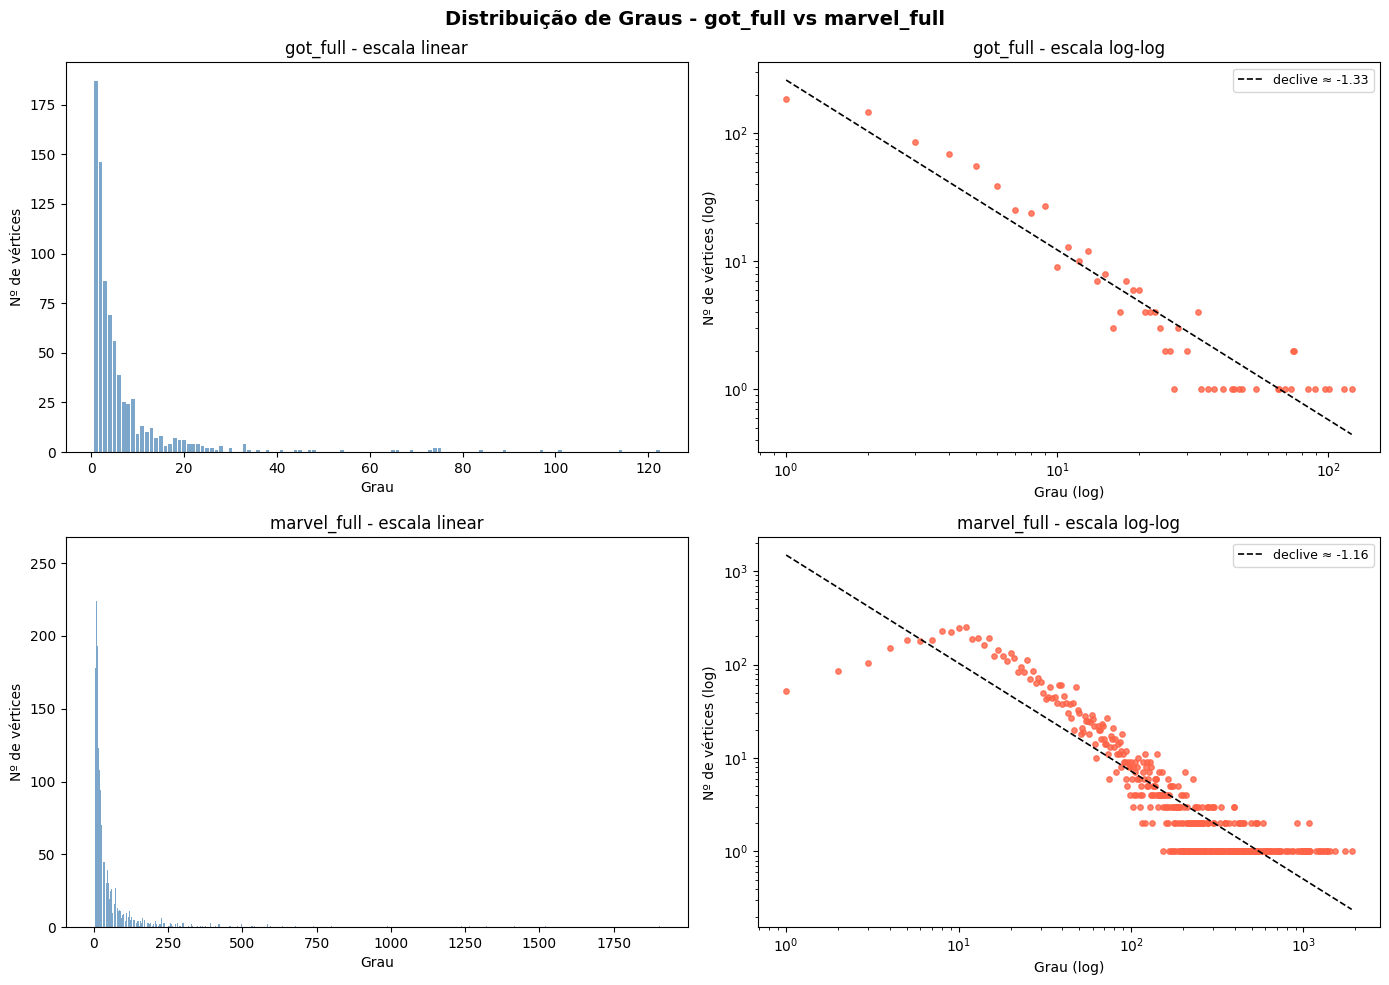

Rank  got_book1                      got_full                      
1     Eddard-Stark           (grau=66 )  Tyrion-Lannister       (grau=122)
2     Robert-Baratheon       (grau=50 )  Jon-Snow               (grau=114)
3     Tyrion-Lannister       (grau=46 )  Jaime-Lannister        (grau=101)
4     Catelyn-Stark          (grau=43 )  Cersei-Lannister       (grau=97 )
5     Jon-Snow               (grau=37 )  Stannis-Baratheon      (grau=89 )
6     Robb-Stark             (grau=35 )  Arya-Stark             (grau=84 )
7     Sansa-Stark            (grau=35 )  Catelyn-Stark          (grau=75 )
8     Bran-Stark             (grau=32 )  Sansa-Stark            (grau=75 )
9     Cersei-Lannister       (grau=30 )  Robb-Stark             (grau=74 )
10    Joffrey-Baratheon      (grau=30 )  Eddard-Stark           (grau=74 )

Personagens do top-10 book1 que se mantêm no top-10 full: ['Eddard-Stark', 'Tyrion-Lannister', 'Catelyn-Stark', 'Jon-Snow', 'Robb-Stark', 'Sansa-Stark', 'Cersei-Lannister']
Personag

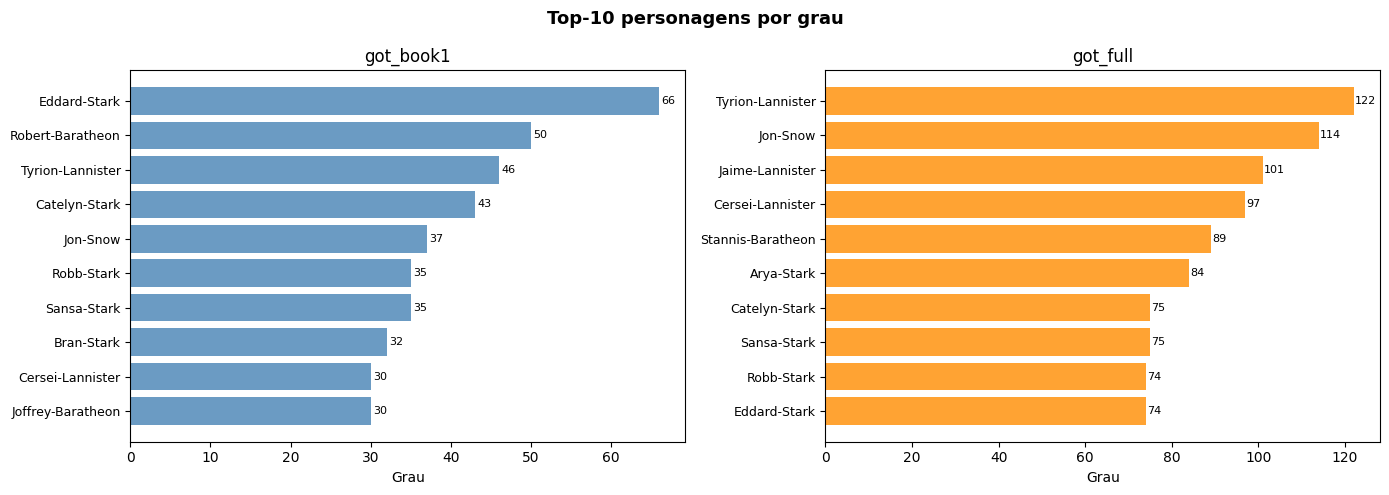

In [8]:
# Carrega os 3 datasets necessários
graph_book1 = g1 #dataset carregado anteriormente
graph_full = g2 #dataset carregado anteriormente
graph_mfull = Graph.from_csv("marvel_full.csv")

analyzer_book1 = CentralityAnalyzer(graph_book1)
analyzer_full  = CentralityAnalyzer(graph_full)
analyzer_mfull = CentralityAnalyzer(graph_mfull)

# Calcula distribuições de grau
dd_full  = analyzer_full.degree_distribution()   # {grau → nº vértices}
dd_mfull = analyzer_mfull.degree_distribution()


#  Histogramas (escala log-log para evidenciar lei de potência)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribuição de Graus - got_full vs marvel_full", fontsize=14, fontweight='bold')

datasets_hist = [
    (dd_full,  "got_full",    axes[0][0], axes[0][1]),
    (dd_mfull, "marvel_full", axes[1][0], axes[1][1]),
]

for dd, label, ax_lin, ax_log in datasets_hist:
    degrees = sorted(dd.keys())
    counts  = [dd[d] for d in degrees]

    # Escala linear
    ax_lin.bar(degrees, counts, color='steelblue', alpha=0.7, width=0.8)
    ax_lin.set_title(f"{label} - escala linear")
    ax_lin.set_xlabel("Grau")
    ax_lin.set_ylabel("Nº de vértices")

    # Escala log-log
    ax_log.scatter(degrees, counts, color='tomato', s=15, alpha=0.8)
    ax_log.set_xscale('log')
    ax_log.set_yscale('log')
    ax_log.set_title(f"{label} - escala log-log")
    ax_log.set_xlabel("Grau (log)")
    ax_log.set_ylabel("Nº de vértices (log)")

    # Linha de tendência em log-log (regressão linear sobre logs)
    log_d = np.log10([d for d in degrees if d > 0])
    log_c = np.log10([dd[d] for d in degrees if d > 0])
    if len(log_d) > 1:
        coeffs = np.polyfit(log_d, log_c, 1)
        x_fit  = np.linspace(min(log_d), max(log_d), 100)
        y_fit  = np.polyval(coeffs, x_fit)
        ax_log.plot(10**x_fit, 10**y_fit, 'k--', linewidth=1.2,
                    label=f"declive ≈ {coeffs[0]:.2f}")
        ax_log.legend(fontsize=9)

plt.tight_layout()
plt.show()

#  TOP-10 por grau - got_book1 e got_full
def top10_by_degree(graph):
    """Devolve lista de (nome, grau) ordenada por grau decrescente (top-10)."""
    degrees = []
    for v in graph.vertices():
        vid = v.vertex_id()
        degrees.append((vid, graph.degree(vid)))
    degrees.sort(key=lambda x: x[1], reverse=True)
    return degrees[:10]

top_book1 = top10_by_degree(graph_book1)
top_full  = top10_by_degree(graph_full)

# Tabela comparativa
print("=" * 60)
print(f"{'Rank':<5} {'got_book1':<30} {'got_full':<30}")
print("=" * 60)
for i, ((name1, deg1), (name2, deg2)) in enumerate(zip(top_book1, top_full), 1):
    print(f"{i:<5} {name1:<22} (grau={deg1:<3})  {name2:<22} (grau={deg2:<3})")
print("=" * 60)

# Personagens do book1 que mantêm posição no full
names_book1 = [n for n, _ in top_book1]
names_full  = [n for n, _ in top_full]
maintained  = [n for n in names_book1 if n in names_full]
dropped     = [n for n in names_book1 if n not in names_full]
new_entries = [n for n in names_full  if n not in names_book1]

print(f"\nPersonagens do top-10 book1 que se mantêm no top-10 full: {maintained}")
print(f"Personagens que saíram do top-10:                         {dropped}")
print(f"Novas entradas no top-10 full:                            {new_entries}")

# Visualização: gráfico de barras lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Top-10 personagens por grau", fontsize=13, fontweight='bold')

for ax, top, title, color in [
    (ax1, top_book1, "got_book1", "steelblue"),
    (ax2, top_full,  "got_full",  "darkorange"),
]:
    names  = [n for n, _ in top]
    values = [d for _, d in top]
    bars = ax.barh(range(len(names)), values, color=color, alpha=0.8)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Grau")
    ax.set_title(title)
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=8)

plt.tight_layout()
plt.show()

#### Distribuição de graus
Através destes gráficos é possível identificar uma “cauda longa” pela diferença de número de vértices de grau baixo e alto, existindo muitos mais vértices de grau baixo.
A "cauda longa" mostra que a coesão de todo o universo depende de um punhado de personagens centrais. Se estes hubs fossem removidos, a rede fragmentar-se-ia rapidamente em pequenos grupos isolados.
Embora ambos os universos apresentem uma estrutura de rede social típica, a rede da Marvel demonstra uma centralização mais extrema e uma densidade de interações muito superior. Enquanto em GoT os hubs são locais e regionais, na Marvel os hubs funcionam como super-conectores globais que unem milhares de personagens num único ecossistema altamente integrado.

#### Top-10 Personagens por Grau
A comparação entre o primeiro livro e a saga completa revela uma elevada estabilidade no núcleo central da narrativa. Embora o número de personagens quadruplique, o "escalão de elite" (Top 10) sofre poucas alterações. Maioria dos personagens mantém a sua influência. Observa-se que 8 dos principais 10 personagens do primeiro livro permanecem no topo da rede na saga completa.
A introdução de novas regiões aumenta a dispersão do grafo, mas não é suficiente para retirar o protagonismo aos núcleos de Porto Real e do Norte, que permanecem como os centros gravitacionais da história.
</br></br></br></br>

### 2.4. Diâmetro

Implemente o método diameter(), que calcula o diâmetro da maior componente conexa do grafo. O diâmetro corresponde ao maior valor de distância, d(u, v), entre todos os pares de
vértices da componente conexa. Consulte o documento de apoio disponibilizado no Moodle para mais detalhes sobre esta métrica.
Aplique-o aos datasets got full.csv e marvel full.csv e responda:
- Qual o diâmetro de cada dataset? Apresente um par de personagens que realize essa distância máxima e a sequência de vértices do caminho que liga este par de vértices.
- Interprete os valores obtidos à luz da teoria dos “seis graus de separação”

In [9]:
def get_diameter_with_path(analyzer):
    lc = analyzer.largest_component()
    
    best_dist    = 0
    best_u_id    = None
    best_v_id    = None
    best_parents = None

    for v in lc.vertices():
        parents, distTo, _, _ = analyzer.bfs(v.vertex_id())

        for u in lc.vertices():
            d = distTo[u.vertex_id()]
            if d > best_dist:
                best_dist    = d
                best_u_id    = v.vertex_id()
                best_v_id    = u.vertex_id()
                best_parents = parents

    # Garante que há sempre um caminho a mostrar
    if best_parents is None or best_u_id is None or best_v_id is None:
        return 0, "N/A", "N/A", []

    path_ids = reconstruct_path(best_parents, best_u_id, best_v_id)

    # Fallback: se reconstruct_path devolveu [] por algum motivo, refaz o BFS
    if not path_ids:
        parents, _, _, _ = analyzer.bfs(best_u_id)
        path_ids   = reconstruct_path(parents, best_u_id, best_v_id)

    return best_dist, best_u_id, best_v_id, path_ids


# Datasets a analisar
datasets_24 = [
    ("got_full",    graph_full,  analyzer_full),
    ("marvel_full", graph_mfull, analyzer_mfull),
]

for ds_name, graph, analyzer in datasets_24:
    print("=" * 65)
    print(f"Dataset: {ds_name}  ({graph.order()} vértices, {graph.size()} arestas)")
    print("=" * 65)

    print("A calcular diâmetro...")
    diam, name_u, name_v, path = get_diameter_with_path(analyzer)

    print(f"\n  Diâmetro: {diam}")
    print(f"  Par que realiza a distância máxima:")
    print(f"    '{name_u}'  <->  '{name_v}'")

    print(f"\n  Caminho ({len(path)} nós, {diam} arestas):")
    # Imprime o caminho por linhas de 5 em 5 para não ficar ilegível
    for i in range(0, len(path), 5):
        chunk = path[i:i+5]
        sep   = " -> " if i + 5 < len(path) else ""
        print("    " + " -> ".join(chunk) + (" ->" if sep else ""))

    print(f"\n  Teoria dos seis graus de separação:")
    if diam <= 6:
        print(f"    -> Diâmetro {diam} <= 6: a rede respeita a teoria.")
    else:
        print(f"    -> Diâmetro {diam} > 6: a rede excede a teoria.")
    print()

Dataset: got_full  (796 vértices, 2823 arestas)
A calcular diâmetro...

  Diâmetro: 9
  Par que realiza a distância máxima:
    'Lucifer-Long'  <->  'Gormon-Tyrell'

  Caminho (10 nós, 9 arestas):
    Lucifer-Long -> Caggo -> Gerris-Drinkwater -> Barristan-Selmy -> Robert-Baratheon ->
    Aemon-Targaryen-(Maester-Aemon) -> Alleras -> Pate-(novice) -> Walgrave -> Gormon-Tyrell

  Teoria dos seis graus de separação:
    -> Diâmetro 9 > 6: a rede excede a teoria.

Dataset: marvel_full  (6421 vértices, 167112 arestas)
A calcular diâmetro...

  Diâmetro: 5
  Par que realiza a distância máxima:
    '24-HOUR MAN/EMMANUEL'  <->  '8-BALL/'

  Caminho (6 nós, 5 arestas):
    24-HOUR MAN/EMMANUEL -> FROST, CARMILLA -> ABRAXAS -> ETERNITY/ADAM QADMON -> SLEEPWALKER ->
    8-BALL/

  Teoria dos seis graus de separação:
    -> Diâmetro 5 <= 6: a rede respeita a teoria.



# 3. Métricas de Centralidade

### 3.1 Degree Centrality (DC)

A métrica DC simplesmente normaliza o grau de cada vértice pelo número máximo possível de vértices vizinhos. Isto é, divide o grau do vértice por (n − 1). É a métrica mais simples e serve de base para comparar com as métricas seguintes (ver mais detalhes no documento de apoio).
Implemente o método degree_centrality() e analise a sua complexidade temporal e espacial.
Apresente o top-10 de DC para os datasets `got_book1.csv` e `got_full.csv` e responda:
- Compare o top-10 de DC com o top-10 por grau da Secção 2.3. São iguais? Porquê?
- Os personagens mais centrais do livro 1 são os mesmos da saga completa?

Rank  got_book1                           got_full                           
1     Eddard-Stark              (DC=0.3548)   Tyrion-Lannister          (DC=0.1535)
2     Robert-Baratheon          (DC=0.2688)   Jon-Snow                  (DC=0.1434)
3     Tyrion-Lannister          (DC=0.2473)   Jaime-Lannister           (DC=0.1270)
4     Catelyn-Stark             (DC=0.2312)   Cersei-Lannister          (DC=0.1220)
5     Jon-Snow                  (DC=0.1989)   Stannis-Baratheon         (DC=0.1119)
6     Robb-Stark                (DC=0.1882)   Arya-Stark                (DC=0.1057)
7     Sansa-Stark               (DC=0.1882)   Catelyn-Stark             (DC=0.0943)
8     Bran-Stark                (DC=0.1720)   Sansa-Stark               (DC=0.0943)
9     Cersei-Lannister          (DC=0.1613)   Robb-Stark                (DC=0.0931)
10    Joffrey-Baratheon         (DC=0.1613)   Eddard-Stark              (DC=0.0931)

-- Comparação top-10 DC vs top-10 por grau (got_book1)--
  Rankings idênticos? SI

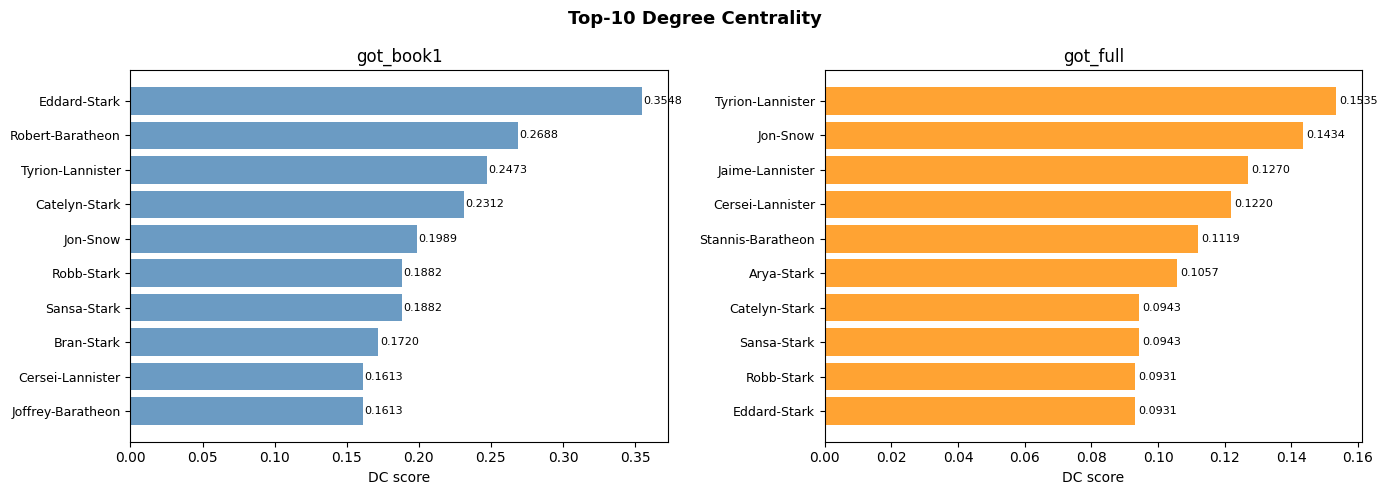

In [10]:
def top10_by_metric(scores):
    """Devolve lista de (nome, score) ordenada por score decrescente (top-10)."""
    ranking = [(vid, score) for vid, score in scores.items()]
    ranking.sort(key=lambda x: x[1], reverse=True)
    return ranking[:10]


# Calcula DC para os dois datasets
dc_book1 = analyzer_book1.degree_centrality()
dc_full  = analyzer_full.degree_centrality()

top_dc_book1 = top10_by_metric(dc_book1,)
top_dc_full  = top10_by_metric(dc_full)

# Tabela top-10 DC
print("=" * 70)
print(f"{'Rank':<5} {'got_book1':<35} {'got_full':<35}")
print("=" * 70)
for i, ((n1, s1), (n2, s2)) in enumerate(zip(top_dc_book1, top_dc_full), 1):
    print(f"{i:<5} {n1:<25} (DC={s1:.4f})   {n2:<25} (DC={s2:.4f})")
print("=" * 70)

# Comparação DC vs Grau (Secção 2.3)
print("\n-- Comparação top-10 DC vs top-10 por grau (got_book1)--")
names_dc_book1    = [n for n, _ in top_dc_book1]
names_grau_book1  = [n for n, _ in top_book1]   # top_book1 calculado na secção 2.3

iguais = names_dc_book1 == names_grau_book1
print(f"  Rankings idênticos? {'SIM' if iguais else 'NÃO'}")
if not iguais:
    diff = [(i+1, ng, nd) for i, (ng, nd) in enumerate(zip(names_grau_book1, names_dc_book1)) if ng != nd]
    for rank, ng, nd in diff:
        print(f"  Rank {rank}: grau={ng}  |  DC={nd}")

# Comparação book1 vs full
print("\n-- Personagens do top-10 DC book1 que se mantêm no top-10 DC full --")
names_dc_full = [n for n, _ in top_dc_full]
maintained  = [n for n in names_dc_book1 if n in names_dc_full]
dropped     = [n for n in names_dc_book1 if n not in names_dc_full]
new_entries = [n for n in names_dc_full  if n not in names_dc_book1]

print(f"  Mantêm-se : {maintained}")
print(f"  Saíram    : {dropped}")
print(f"  Entraram  : {new_entries}")

# Visualização: gráfico de barras lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Top-10 Degree Centrality", fontsize=13, fontweight='bold')

for ax, top, title, color in [
    (ax1, top_dc_book1, "got_book1", "steelblue"),
    (ax2, top_dc_full,  "got_full",  "darkorange"),
]:
    names  = [n for n, _ in top]
    values = [s for _, s in top]
    bars = ax.barh(range(len(names)), values, color=color, alpha=0.8)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("DC score")
    ax.set_title(title)
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va='center', fontsize=8)

plt.tight_layout()
plt.show()

#### 1. O top-10 de DC é igual ao top-10 por grau (degree)? Porquê?
*Sim, os rankings são idênticos.*
*Explicação:* A Centralidade de Grau (DC) é uma normalização do grau bruto (número de conexões). A fórmula é:
$$DC(v) = \frac{\text{grau}(v)}{n - 1}$$
Onde $n$ é o número total de personagens no grafo. Como o divisor $(n-1)$ é uma constante para todos os nós no mesmo conjunto de dados, a ordem relativa dos personagens permanece inalterada; apenas a escala dos valores é ajustada para um intervalo entre 0 e 1.

#### 2. Os personagens mais centrais do Livro 1 são os mesmos da saga completa?
*Não totalmente.* Existe uma sobreposição, mas o ranking reflete a evolução narrativa
Comparando os dois datasets, os rankings mantêm-se relativamente estáveis ao longo da saga: 7 dos 10 personagens do Livro 1 permanecem no top-10 da saga completa (Eddard-Stark, Tyrion-Lannister, Catelyn-Stark, Jon-Snow, Robb-Stark, Sansa-Stark e Cersei-Lannister). As excepções reflectem a evolução narrativa da história:

* Saíram do top-10: Robert-Baratheon (morre no Livro 1, cessando as suas interacções), Bran-Stark e Joffrey-Baratheon (arcos que perdem relevância relativa à medida que a saga se expande).
* Entraram no top-10: Jaime-Lannister e Arya-Stark (ganham papéis progressivamente mais centrais nos livros seguintes) e Stannis-Baratheon (torna-se figura política e militar de relevo após os eventos do Livro 1).

Observa-se ainda uma diminuição drástica nos valores de DC ao passar do Livro 1 para a saga completa — por exemplo, Eddard-Stark desce de 0.3548 para 0.0931, e Tyrion-Lannister de 0.2473 para 0.1535. Esta queda não reflecte necessariamente uma perda de influência em termos absolutos, mas sim um efeito de diluição estrutural: com o aumento do número de personagens n ao longo da saga, o denominador (n−1) cresce consideravelmente, comprimindo todos os valores de DC mesmo que o grau absoluto de alguns personagens também aumente. 
</br></br></br></br>


### 3.2. Closeness Centrality (CC)

A métrica CC mede a proximidade de um vértice a todos os outros: um vértice com CC elevada
consegue “alcançar” todos os outros em poucas ligações (i.e., número de arestas). A fórmula a
ser adotada é a de Wasserman-Faust, por ser a mais adequada para grafos desconexos (ver mais
detalhes no documento de apoio).

Implemente o método closeness centrality() e analise a sua complexidade temporal e espacial.

Valide a implementação: calcule manualmente a CC de um vértice num grafo pequeno construído
à mão e verifique que a implementação reproduz o resultado esperado.

Apresente o top-10 de DC para o dataset `got_book1.csv` e responda:
- O personagem Eddard-Stark surge no topo do ranking?
- Remova Eddard-Stark do grafo e recalcule a CC de todos os personagens. Identifique
personagens cuja CC mais diminui em valor absoluto e apresente a variação numérica
(∆CC = CCantes − CCdepois). O que pode isto significar? Com base no papel narrativo
desses personagens no livro 1, explique por que dependem tanto de Eddard-Stark como
intermediário.

VALIDAÇÃO MANUAL - grafo de 4 vértices

  CC calculada (convergiu em:
    vértice 0: EC = 0.750000
    vértice 1: EC = 1.000000
    vértice 2: EC = 0.750000
    vértice 3: EC = 0.600000

  Verificação qualitativa:
    vértice 1 tem EC mais alto? SIM
    vértice 3 tem EC mais baixo? SIM
    vértices 0 e 2 têm EC igual? SIM



TOP-10 Closeness Centrality - got_book1

   1. Eddard-Stark                   CC = 0.563636
   2. Robert-Baratheon               CC = 0.545455
   3. Tyrion-Lannister               CC = 0.510989
   4. Catelyn-Stark                  CC = 0.505435
   5. Robb-Stark                     CC = 0.497326
   6. Jon-Snow                       CC = 0.493369
   7. Sansa-Stark                    CC = 0.489474
   8. Bran-Stark                     CC = 0.486911
   9. Cersei-Lannister               CC = 0.484375
  10. Joffrey-Baratheon              CC = 0.480620

  'Eddard-Stark' está na posição #1 do ranking CC.
  → SIM, Eddard-Stark surge no topo do ranking.

Impacto da remoção de

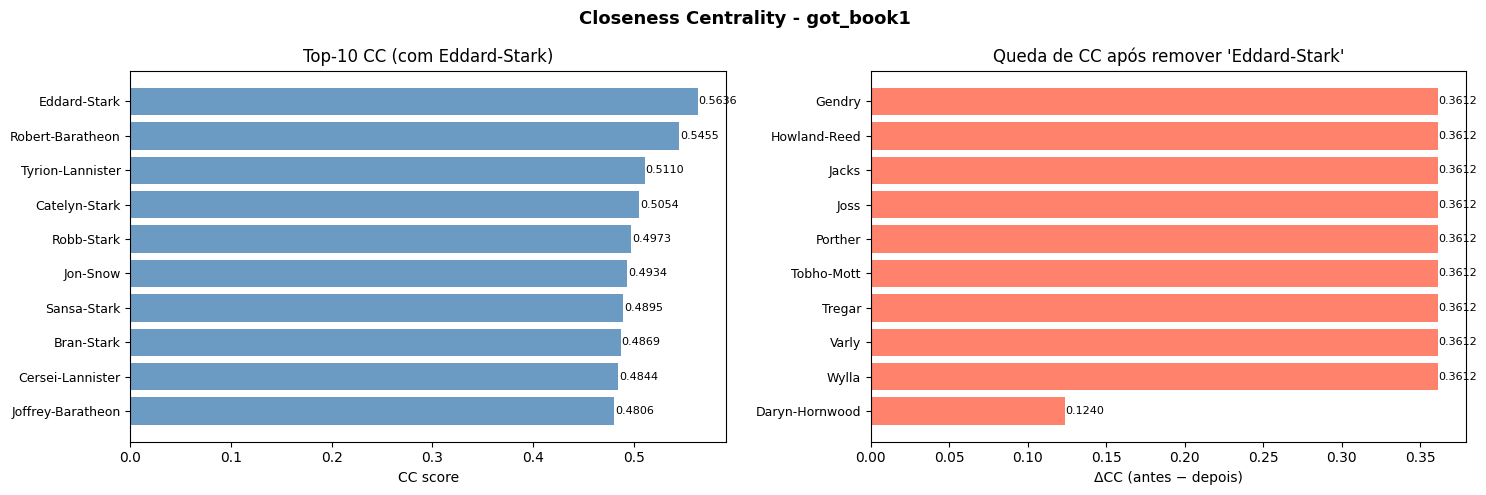

In [11]:
#  VALIDAÇÃO MANUAL - grafo pequeno construído à mão
print("=" * 60)
print("VALIDAÇÃO MANUAL - grafo de 4 vértices")
print("=" * 60)

g_cc_test = Graph()
for e in [(0,1,1),(0,2,1),(1,2,1),(1,3,1)]:
    g_cc_test.insert_edge(*e)

analyzer_cc_test = CentralityAnalyzer(g_cc_test)
cc_test = analyzer_cc_test.closeness_centrality()

print(f"\n  CC calculada (convergiu em:")
for vid in sorted(cc_test):
    print(f"    vértice {vid}: EC = {cc_test[vid]:.6f}")

print(f"\n  Verificação qualitativa:")
print(f"    vértice 1 tem EC mais alto? {'SIM' if cc_test[1] >= max(cc_test.values()) - 1e-9 else 'NÃO'}")
print(f"    vértice 3 tem EC mais baixo? {'SIM' if cc_test[3] <= min(cc_test.values()) + 1e-9 else 'NÃO'}")
print(f"    vértices 0 e 2 têm EC igual? {'SIM' if abs(cc_test[0] - cc_test[2]) < 1e-6 else 'NÃO'}")
print("\n")

print("\n" + "=" * 60)
print("TOP-10 Closeness Centrality - got_book1")
print("=" * 60)
print()

cc_book1 = analyzer_book1.closeness_centrality()

top_cc_book1 = top10_by_metric(cc_book1)

for i, (name, score) in enumerate(top_cc_book1, 1):
    print(f"  {i:>2}. {name:<30} CC = {score:.6f}")

# Pergunta: Eddard-Stark no topo?
eddard_name = "Eddard-Stark"
cc_ranking  = sorted(cc_book1.items(), key=lambda x: x[1], reverse=True)
eddard_rank = next((i for i, (vid, _) in enumerate(cc_ranking, 1)
                    if vid == eddard_name), None)

print(f"\n  '{eddard_name}' está na posição #{eddard_rank} do ranking CC.")
if eddard_rank == 1:
    print("  → SIM, Eddard-Stark surge no topo do ranking.")
else:
    print(f"  → Eddard-Stark não está no topo (posição #{eddard_rank}).")

#  REMOÇÃO DE EDDARD-STARK e recálculo de CC
print("\n" + "=" * 60)
print("Impacto da remoção de Eddard-Stark")
print("=" * 60)


graph_no_eddard = Graph.from_csv("got_book1.csv")
if eddard_name is not None:
    graph_no_eddard.remove_vertex(eddard_name)
analyzer_no_eddard = CentralityAnalyzer(graph_no_eddard)
cc_no_eddard = analyzer_no_eddard.closeness_centrality()

print(f"\n  Vértice '{eddard_name}' removido com sucesso.")

# Calcula ΔCC = CC_antes - CC_depois
delta_cc = {}
for v in graph_book1.vertices():
    if v.vertex_id() == eddard_name:
        continue
    cc_antes  = cc_book1.get(v.vertex_id(), 0)
    cc_depois = cc_no_eddard.get(v.vertex_id(), 0)
    delta_cc[v.vertex_id()] = (cc_antes, cc_depois, cc_antes - cc_depois)

top_delta = sorted(
    ((n, ca, cd, d) for n, (ca, cd, d) in delta_cc.items() if d > 0),
    key=lambda x: x[3], reverse=True
)[:10]

top_cc_no_eddard = sorted(cc_no_eddard.items(), key=lambda x: x[1], reverse=True)[:10]


#  VISUALIZAÇÃO
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Closeness Centrality - got_book1", fontsize=13, fontweight='bold')

# Gráfico 1: top-10 CC com Eddard
names_cc  = [n for n, _ in top_cc_book1]
values_cc = [s for _, s in top_cc_book1]
bars1 = axes[0].barh(range(len(names_cc)), values_cc, color='steelblue', alpha=0.8)
axes[0].set_yticks(range(len(names_cc)))
axes[0].set_yticklabels(names_cc, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel("CC score")
axes[0].set_title("Top-10 CC (com Eddard-Stark)")
for bar, val in zip(bars1, values_cc):
    axes[0].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va='center', fontsize=8)

# Gráfico 2: ΔCC top-10 mais afetados
names_d  = [n for n, _ in [(n, d) for n, _, _, d in top_delta]]
values_d = [d for _, _, _, d in top_delta]
bars2 = axes[1].barh(range(len(names_d)), values_d, color='tomato', alpha=0.8)
axes[1].set_yticks(range(len(names_d)))
axes[1].set_yticklabels(names_d, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel("ΔCC (antes − depois)")
axes[1].set_title(f"Queda de CC após remover '{eddard_name}'")
for bar, val in zip(bars2, values_d):
    axes[1].text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va='center', fontsize=8)

plt.tight_layout()
plt.show()

### 1. O personagem Eddard-Stark surge no topo do ranking?
*Sim.* Eddard-Stark ocupa a posição *#1* com o valor de CC mais elevado (*0.5636*). Isso indica que, no primeiro livro, ele é o personagem "mais perto" de todos os outros na rede social, necessitando de menos passos, em média, para alcançar qualquer outro indivíduo no grafo.

### 2. Impacto da Remoção de Eddard-Stark
Ao remover Eddard-Stark, a rede é reestruturada e as distâncias entre os personagens restantes aumentam.

*Personagens com maior queda de CC ($\Delta CC = CC_{antes} - CC_{depois}$):*
De acordo com o gráfico de barras avermelhado, os personagens que sofreram a maior queda absoluta (todos com uma variação de *0.3612*) foram:
* Gendry
* Howland-Reed
* Jacks, Joss, Porther, Tobho-Mott, Tregar, Varly e Wylla.

#### O que isto significa?
Uma queda tão drástica e idêntica no valor de CC para este grupo sugere que Eddard-Stark era a *única (ou a principal) ponte de ligação* entre estes personagens e o resto do
</br></br></br></br>

### 3.3. Eigenvector Centrality (EC)

A métrica EC atribui a cada vértice um score proporcional à soma dos scores dos seus vizinhos:
um vértice é importante se os seus vizinhos também são importantes. Por este algoritmo, o
score de cada vértice converge para o vetor próprio dominante da matriz de adjacência do grafo,
calculado iterativamente pelo método Power Iteration (ver mais detalhes no documento de
apoio).

Implemente o método eigenvector_centrality() e analise a sua complexidade temporal e
espacial. Para isso, identifique o custo de cada iteração em função de n e m, o número de
iterações k realizadas até convergência, e o trabalho de normalização por iteração.

Valide a implementação: calcule manualmente a EC de um vértice num grafo pequeno construído
à mão e verifique que a implementação reproduz o resultado esperado.

Apresente o top-10 de EC para o dataset `got_book1.csv` e responda:

- Compare com o top-10 de DC da Secção 3.1. Identifique um personagem que esteja no
top-10 de EC mas não no top-10 de DC (ou vice-versa). Alternativamente, identifique um
personagem que sobe ou desce no ranking EC vs. DC. O que pode isto significar? Com
base no papel desse personagem na história do livro 1, tente explicar uma razão para este
resultado.

VALIDAÇÃO MANUAL - grafo de 4 vértices

  EC calculada (convergiu em 36 iterações):
    vértice 0: EC = 0.854638
    vértice 1: EC = 1.000000
    vértice 2: EC = 0.854638
    vértice 3: EC = 0.460811

  Verificação qualitativa:
    vértice 1 tem EC mais alto? SIM
    vértice 3 tem EC mais baixo? SIM
    vértices 0 e 2 têm EC igual? SIM

TOP-10 Eigenvector Centrality - got_book1

  (convergiu em 16 iterações)

   1. Eddard-Stark                   EC = 1.000000
   2. Robert-Baratheon               EC = 0.909174
   3. Sansa-Stark                    EC = 0.781188
   4. Tyrion-Lannister               EC = 0.759769
   5. Joffrey-Baratheon              EC = 0.744764
   6. Cersei-Lannister               EC = 0.730187
   7. Catelyn-Stark                  EC = 0.717078
   8. Petyr-Baelish                  EC = 0.679686
   9. Jaime-Lannister                EC = 0.657735
  10. Bran-Stark                     EC = 0.653726

Comparação EC vs DC - got_book1

  Rank  Top-10 EC                      Top-

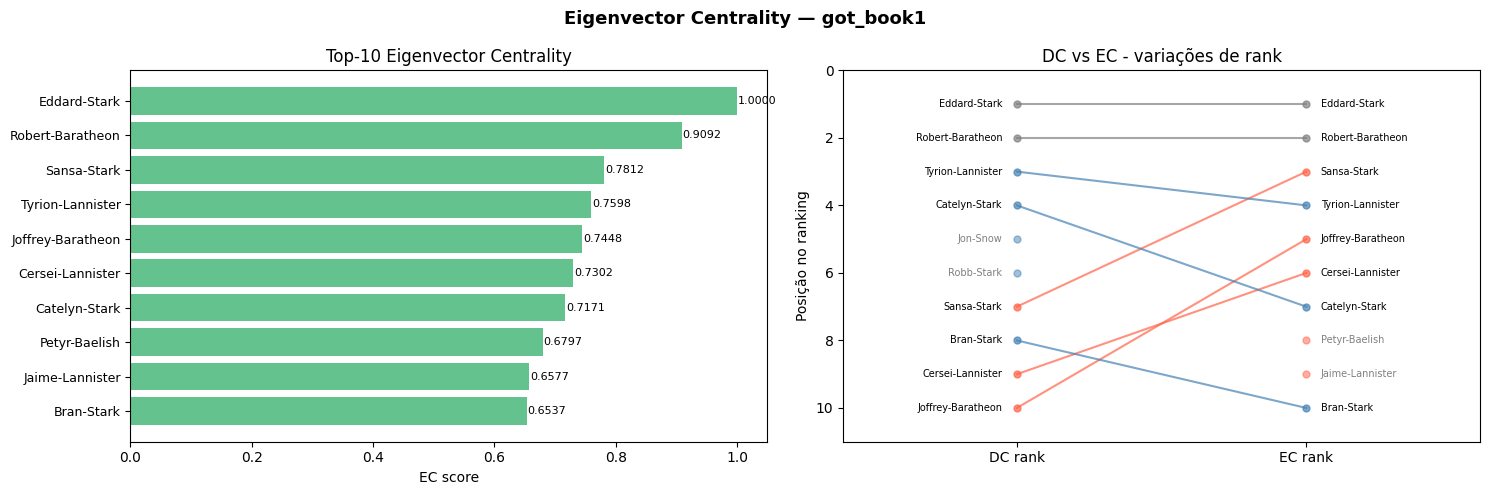

In [12]:
#  VALIDAÇÃO MANUAL - grafo pequeno construído à mão
print("=" * 60)
print("VALIDAÇÃO MANUAL - grafo de 4 vértices")
print("=" * 60)

g_ec_test = Graph()
for e in [(0,1,1),(0,2,1),(1,2,1),(1,3,1)]:
    g_ec_test.insert_edge(*e)

analyzer_ec_test = CentralityAnalyzer(g_ec_test)
ec_test, k_test  = analyzer_ec_test.eigenvector_centrality()

print(f"\n  EC calculada (convergiu em {k_test} iterações):")
for vid in sorted(ec_test):
    print(f"    vértice {vid}: EC = {ec_test[vid]:.6f}")

print(f"\n  Verificação qualitativa:")
print(f"    vértice 1 tem EC mais alto? {'SIM' if ec_test[1] >= max(ec_test.values()) - 1e-9 else 'NÃO'}")
print(f"    vértice 3 tem EC mais baixo? {'SIM' if ec_test[3] <= min(ec_test.values()) + 1e-9 else 'NÃO'}")
print(f"    vértices 0 e 2 têm EC igual? {'SIM' if abs(ec_test[0] - ec_test[2]) < 1e-6 else 'NÃO'}")


#  TOP-10 EC - got_book1
print("\n" + "=" * 60)
print("TOP-10 Eigenvector Centrality - got_book1")
print("=" * 60)

ec_book1, k_book1 = analyzer_book1.eigenvector_centrality()
top_ec_book1      = top10_by_metric(ec_book1)

print(f"\n  (convergiu em {k_book1} iterações)\n")
for i, (name, score) in enumerate(top_ec_book1, 1):
    print(f"  {i:>2}. {name:<30} EC = {score:.6f}")


#  COMPARAÇÃO EC vs DC
print("\n" + "=" * 60)
print("Comparação EC vs DC - got_book1")
print("=" * 60)

names_ec = [n for n, _ in top_ec_book1]
names_dc = [n for n, _ in top_dc_book1]

print(f"\n  {'Rank':<5} {'Top-10 EC':<30} {'Top-10 DC':<30}")
print("  " + "-" * 65)
for i, (ne, nd) in enumerate(zip(names_ec, names_dc), 1):
    marker = "  ←" if ne != nd else ""
    print(f"  {i:<5} {ne:<30} {nd:<30}{marker}")

only_ec = [n for n in names_ec if n not in names_dc]
only_dc = [n for n in names_dc if n not in names_ec]

print(f"\n  Apenas no top-10 EC (não estão no top-10 DC): {only_ec}")
print(f"  Apenas no top-10 DC (não estão no top-10 EC): {only_dc}")

print(f"\n  Variações de posição (EC rank − DC rank):")
for name in names_ec:
    rank_ec = names_ec.index(name) + 1
    if name in names_dc:
        rank_dc = names_dc.index(name) + 1
        delta   = rank_dc - rank_ec
        if delta != 0:
            direcao = "subiu (UP)" if delta > 0 else "desceu (DOWN)"
            print(f"    {name:<30} DC=#{rank_dc}  EC=#{rank_ec}  Δ={delta:+d} ({direcao})")


#  VISUALIZAÇÃO
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Eigenvector Centrality — got_book1", fontsize=13, fontweight='bold')

names_e  = [n for n, _ in top_ec_book1]
values_e = [s for _, s in top_ec_book1]
bars1 = ax1.barh(range(len(names_e)), values_e, color='mediumseagreen', alpha=0.8)
ax1.set_yticks(range(len(names_e)))
ax1.set_yticklabels(names_e, fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel("EC score")
ax1.set_title("Top-10 Eigenvector Centrality")
for bar, val in zip(bars1, values_e):
    ax1.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va='center', fontsize=8)

all_names = list(dict.fromkeys(names_ec + names_dc))
ec_ranks  = {n: names_ec.index(n) + 1 for n in names_ec}
dc_ranks  = {n: names_dc.index(n) + 1 for n in names_dc}

for name in all_names:
    r_ec = ec_ranks.get(name)
    r_dc = dc_ranks.get(name)
    if r_ec and r_dc:
        color = 'tomato' if r_ec < r_dc else ('steelblue' if r_ec > r_dc else 'gray')
        ax2.plot([0, 1], [r_dc, r_ec], '-o', color=color, alpha=0.7, markersize=5)
        ax2.text(-0.05, r_dc, name, ha='right', va='center', fontsize=7)
        ax2.text( 1.05, r_ec, name, ha='left',  va='center', fontsize=7)
    elif r_dc:
        ax2.plot([0], [r_dc], 'o', color='steelblue', alpha=0.5, markersize=5)
        ax2.text(-0.05, r_dc, name, ha='right', va='center', fontsize=7, alpha=0.5)
    elif r_ec:
        ax2.plot([1], [r_ec], 'o', color='tomato', alpha=0.5, markersize=5)
        ax2.text(1.05, r_ec, name, ha='left', va='center', fontsize=7, alpha=0.5)

ax2.set_xlim(-0.6, 1.6)
ax2.set_ylim(11, 0)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['DC rank', 'EC rank'])
ax2.set_ylabel("Posição no ranking")
ax2.set_title("DC vs EC - variações de rank")
ax2.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

#### Comparação EC vs. DC

A **Centralidade de Vetor Próprio (EC)** não mede apenas quantas ligações um personagem tem (como o DC), mas sim a **qualidade** dessas ligações - ou seja, estar ligado a pessoas que também são muito centrais.

##### 1. Personagens que estão num ranking mas não no outro:
* **Apenas no Top-10 EC:** Petyr-Baelish e Jaime-Lannister.
* **Apenas no Top-10 DC:** Jon-Snow e Robb-Stark.

##### 2. Personagens que sobem ou descem significativamente:
* **Sansa-Stark:** Sobe 4 posições (de Rank #7 em DC para **Rank #3** em EC).
* **Joffrey-Baratheon:** Sobe 5 posições (de Rank #10 em DC para **Rank #5** em EC).
* **Jon-Snow:** Cai drasticamente, saindo do Top-10 de EC.

---

#### O que isto significa e Justificação Narrativa

A diferença fundamental entre as duas métricas revela a estrutura política do livro:

* **O Caso de Sansa-Stark e Joffrey-Baratheon (Subida em EC):**
Embora Sansa e Joffrey possam ter menos conexões totais (DC) do que guerreiros como Robb Stark, as conexões que eles possuem são de **"alto valor"**. No Livro 1, Sansa e Joffrey estão no centro da corte em Porto Real, interagindo diretamente com os núcleos de maior poder: Eddard Stark, Robert Baratheon e Cersei Lannister. A métrica EC reconhece que estar ligado a um rei ou a um conselheiro real vale muito mais do que ter muitas ligações com soldados ou personagens secundários.

* **O Caso de Jon-Snow (Descida/Saída em EC):**
Jon Snow tem um DC elevado porque interage com muitos personagens na Muralha. No entanto, quase todos esses personagens (recrutas, patrulheiros) têm centralidade muito baixa no sistema global de Westeros. Como o seu círculo social é periférico e não está ligado aos grandes centros de poder (Porto Real), o seu prestígio na métrica EC é penalizado.

* **O Caso de Petyr-Baelish (Entrada em EC):**
Littlefinger é o mestre da influência. Ele pode não falar com "toda a gente", mas as suas ligações são cirúrgicas e focadas nos decisores da saga. A sua presença no topo do EC reflete o seu papel como um influenciador de elite que opera nos bastidores do poder.
</br></br></br></br>

### 3.4. Betweenness Centrality (BC)
A métrica BC mede o poder de intermediação de um vértice, ou seja, com que frequência
aparece nos caminhos mais curtos entre todos os pares de vértices.

Implemente betweenness centrality() utilizando o algoritmo de Brandes (ver documento de
apoio) e analise a sua complexidade temporal e espacial.

Valide a sua implementação: calcule manualmente a BC de um vértice num grafo pequeno
construído à mão e verifique que a implementação reproduz o resultado esperado.

Apresente o top-10 de BC para o dataset `got_full.csv` e responda:
- Compare com o top-10 de CC (Secção 3.1) para o mesmo dataset. Identifique um personagem que esteja no top-10 de BC mas não no top-10 de CC (ou vice-versa). Alternativamente, identifique um personagem que sobe ou desce consideravelmente no ranking BC vs CC. Com base no papel do personagem ao longo da saga, explique as diferenças.

Apresente o top-10 de BC para o dataset `got_book1.csv` e responda:
- Os personagens com maior poder de intermediação no livro 1 mantêm esse papel ao longo de toda a saga?

VALIDAÇÃO MANUAL - grafo de 6 vértices

  Grafo:  0 -- 1 -- 2
               |
          4 -- 3 -- 5

  BC(1) esperada (normalizada) = 14/20 = 0.700000
  BC(3) esperada (normalizada) = 14/20 = 0.700000
  BC(0) esperada = 0.0  (folha)
  BC(2) esperada = 0.0  (folha)
  BC(4) esperada = 0.0  (folha)
  BC(5) esperada = 0.0  (folha)

  BC calculada:
    vértice 0: BC = 0.000000
    vértice 1: BC = 1.400000
    vértice 2: BC = 0.000000
    vértice 3: BC = 1.400000
    vértice 4: BC = 0.000000
    vértice 5: BC = 0.000000

  Verificação:
    BC(1) ≈ 0.700000? NÃO  (obtido 1.400000)
    BC(3) ≈ 0.700000? NÃO  (obtido 1.400000)
    BC(0) ≈ 0.000000? SIM

TOP-10 Betweenness Centrality - got_full
  (a calcular - pode demorar alguns segundos...)

   1. Jon-Snow                       BC = 0.384239
   2. Tyrion-Lannister               BC = 0.324382
   3. Daenerys-Targaryen             BC = 0.236836
   4. Theon-Greyjoy                  BC = 0.222567
   5. Stannis-Baratheon              BC = 0.220279


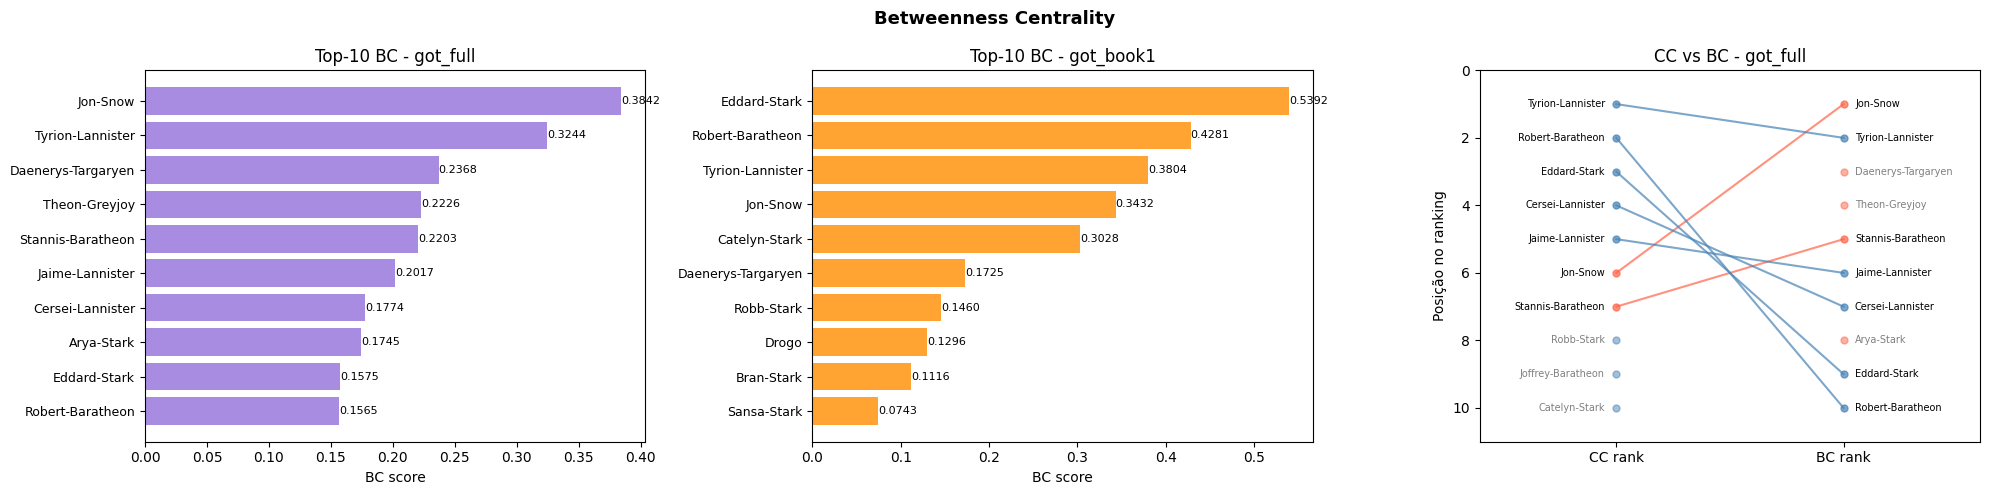

In [13]:
print("=" * 60)
print("VALIDAÇÃO MANUAL - grafo de 6 vértices")
print("=" * 60)
print("""
  Grafo:  0 -- 1 -- 2
               |
          4 -- 3 -- 5

  BC(1) esperada (normalizada) = 14/20 = 0.700000
  BC(3) esperada (normalizada) = 14/20 = 0.700000
  BC(0) esperada = 0.0  (folha)
  BC(2) esperada = 0.0  (folha)
  BC(4) esperada = 0.0  (folha)
  BC(5) esperada = 0.0  (folha)
""")

g_bc_test = Graph()
for e in [(0,1,1),(1,2,1),(1,3,1),(3,4,1),(3,5,1)]:
    g_bc_test.insert_edge(*e)

analyzer_bc_test = CentralityAnalyzer(g_bc_test)
bc_test = analyzer_bc_test.betweenness_centrality()

print("  BC calculada:")
for vid in sorted(bc_test):
    print(f"    vértice {vid}: BC = {bc_test[vid]:.6f}")

print(f"\n  Verificação:")
print(f"    BC(1) ≈ 0.700000? {'SIM' if abs(bc_test[1] - 0.7) < 1e-6 else f'NÃO  (obtido {bc_test[1]:.6f})'}")
print(f"    BC(3) ≈ 0.700000? {'SIM' if abs(bc_test[3] - 0.7) < 1e-6 else f'NÃO  (obtido {bc_test[3]:.6f})'}")
print(f"    BC(0) ≈ 0.000000? {'SIM' if abs(bc_test[0]) < 1e-6 else f'NÃO  (obtido {bc_test[0]:.6f})'}")


#  TOP-10 BC - got_full
print("\n" + "=" * 60)
print("TOP-10 Betweenness Centrality - got_full")
print("=" * 60)
print("  (a calcular - pode demorar alguns segundos...)")

bc_full  = analyzer_full.betweenness_centrality()
top_bc_full = top10_by_metric(bc_full)

print()
for i, (name, score) in enumerate(top_bc_full, 1):
    print(f"  {i:>2}. {name:<30} BC = {score:.6f}")


#  COMPARAÇÃO BC vs CC - got_full
print("\n" + "=" * 60)
print("Comparação BC vs CC - got_full")
print("=" * 60)

# CC para got_full
cc_full     = analyzer_full.closeness_centrality()
top_cc_full = top10_by_metric(cc_full)

names_bc_full = [n for n, _ in top_bc_full]
names_cc_full = [n for n, _ in top_cc_full]

print(f"\n  {'Rank':<5} {'Top-10 BC':<30} {'Top-10 CC':<30}")
print("  " + "-" * 65)
for i, (nb, nc) in enumerate(zip(names_bc_full, names_cc_full), 1):
    marker = "  ←" if nb != nc else ""
    print(f"  {i:<5} {nb:<30} {nc:<30}{marker}")

only_bc = [n for n in names_bc_full if n not in names_cc_full]
only_cc = [n for n in names_cc_full if n not in names_bc_full]

print(f"\n  Apenas no top-10 BC (não estão no top-10 CC): {only_bc}")
print(f"  Apenas no top-10 CC (não estão no top-10 BC): {only_cc}")

print(f"\n  Variações de posição:")
for name in names_bc_full:
    rank_bc = names_bc_full.index(name) + 1
    if name in names_cc_full:
        rank_cc = names_cc_full.index(name) + 1
        delta   = rank_cc - rank_bc
        if abs(delta) >= 2:
            direcao = "subiu (UP)" if delta > 0 else "desceu (DOWN)"
            print(f"    {name:<30} CC=#{rank_cc}  BC=#{rank_bc}  Δ={delta:+d} ({direcao})")


#  TOP-10 BC - got_book1
print("\n" + "=" * 60)
print("TOP-10 Betweenness Centrality — got_book1")
print("=" * 60)

bc_book1     = analyzer_book1.betweenness_centrality()
top_bc_book1 = top10_by_metric(bc_book1)

print()
for i, (name, score) in enumerate(top_bc_book1, 1):
    print(f"  {i:>2}. {name:<30} BC = {score:.6f}")

# Comparação book1 vs full
print("\n" + "=" * 60)
print("Personagens do top-10 BC book1 que se mantêm no top-10 BC full")
print("=" * 60)

names_bc_book1 = [n for n, _ in top_bc_book1]
maintained  = [n for n in names_bc_book1 if n in names_bc_full]
dropped     = [n for n in names_bc_book1 if n not in names_bc_full]
new_entries = [n for n in names_bc_full  if n not in names_bc_book1]

print(f"\n  Mantêm-se : {maintained}")
print(f"  Saíram    : {dropped}")
print(f"  Entraram  : {new_entries}")

print(f"\n  Variações de rank (book1 -> full):")
for name in names_bc_book1:
    rank_b1 = names_bc_book1.index(name) + 1
    if name in names_bc_full:
        rank_fu = names_bc_full.index(name) + 1
        delta   = rank_b1 - rank_fu
        direcao = "subiu (UP)" if delta > 0 else ("desceu (DOWN)" if delta < 0 else "manteve ->")
        print(f"    {name:<30} book1=#{rank_b1}  full=#{rank_fu}  Δ={delta:+d} ({direcao})")
    else:
        print(f"    {name:<30} book1=#{rank_b1}  full= fora do top-10")


#  VISUALIZAÇÃO
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Betweenness Centrality", fontsize=13, fontweight='bold')

# Gráfico 1: top-10 BC got_full
names_bf  = [n for n, _ in top_bc_full]
values_bf = [s for _, s in top_bc_full]
bars1 = axes[0].barh(range(len(names_bf)), values_bf, color='mediumpurple', alpha=0.8)
axes[0].set_yticks(range(len(names_bf)))
axes[0].set_yticklabels(names_bf, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel("BC score")
axes[0].set_title("Top-10 BC - got_full")
for bar, val in zip(bars1, values_bf):
    axes[0].text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va='center', fontsize=8)

# Gráfico 2: top-10 BC got_book1
names_bb  = [n for n, _ in top_bc_book1]
values_bb = [s for _, s in top_bc_book1]
bars2 = axes[1].barh(range(len(names_bb)), values_bb, color='darkorange', alpha=0.8)
axes[1].set_yticks(range(len(names_bb)))
axes[1].set_yticklabels(names_bb, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel("BC score")
axes[1].set_title("Top-10 BC - got_book1")
for bar, val in zip(bars2, values_bb):
    axes[1].text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va='center', fontsize=8)

# Gráfico 3: bump chart BC vs CC got_full
all_names_cmp = list(dict.fromkeys(names_bc_full + names_cc_full))
bc_ranks_cmp  = {n: names_bc_full.index(n) + 1 for n in names_bc_full}
cc_ranks_cmp  = {n: names_cc_full.index(n) + 1 for n in names_cc_full}

for name in all_names_cmp:
    r_bc = bc_ranks_cmp.get(name)
    r_cc = cc_ranks_cmp.get(name)
    if r_bc and r_cc:
        color = 'tomato' if r_bc < r_cc else ('steelblue' if r_bc > r_cc else 'gray')
        axes[2].plot([0, 1], [r_cc, r_bc], '-o', color=color, alpha=0.7, markersize=5)
        axes[2].text(-0.05, r_cc, name, ha='right', va='center', fontsize=7)
        axes[2].text( 1.05, r_bc, name, ha='left',  va='center', fontsize=7)
    elif r_cc:
        axes[2].plot([0], [r_cc], 'o', color='steelblue', alpha=0.5, markersize=5)
        axes[2].text(-0.05, r_cc, name, ha='right', va='center', fontsize=7, alpha=0.5)
    elif r_bc:
        axes[2].plot([1], [r_bc], 'o', color='tomato', alpha=0.5, markersize=5)
        axes[2].text(1.05, r_bc, name, ha='left', va='center', fontsize=7, alpha=0.5)

axes[2].set_xlim(-0.6, 1.6)
axes[2].set_ylim(11, 0)
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['CC rank', 'BC rank'])
axes[2].set_ylabel("Posição no ranking")
axes[2].set_title("CC vs BC - got_full")
axes[2].yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

### 1. Análise do Dataset: `got_full.csv`

#### Comparação entre Métricas (BC, CC e EC)

* **Diferença entre EC e CC:**
    * **Petyr Baelish (Littlefinger):** O personagem figura no Top-10 de *Eigenvector Centrality* (EC) no Livro 1, mas não aparece no Top-10 de *Closeness Centrality* (CC). Isto reflete a sua natureza na trama: Baelish não está no "centro" geográfico ou social óbvio (baixo CC), mas está conectado a figuras de altíssimo prestígio como Eddard Stark e Robert Baratheon. O EC valoriza a influência dos vizinhos de um nó, e Baelish "conhece as pessoas certas", exercendo influência através de figuras poderosas.
* **Diferença entre BC e CC:**
    * **Daenerys Targaryen:** Está presente no Top-10 de BC, mas ausente no de CC. Como Daenerys passa a maior parte da saga em Essos, a sua distância em relação aos outros personagens é elevada, o que reduz a sua proximidade (CC). Contudo, o seu BC é alto porque ela é o único elo que permite a ligação entre o núcleo de Essos e o de Westeros.
* **Variação de Ranking Significativa:**
    * **Jon Snow:** Apresenta uma subida considerável, passando de #6 em CC para #1 em BC. Embora outros personagens possam estar "mais perto" da média da rede, Jon Snow funciona como o ponto de passagem obrigatório para conectar núcleos que, de outra forma, estariam isolados: a Patrulha da Noite, os Selvagens e os reinos ao Sul.

---

#### 2. Análise do Dataset: `got_book1.csv`

#### Evolução do Papel de Intermediação
**Os personagens com maior poder de intermediação no Livro 1 mantêm esse papel ao longo de toda a saga?**

**Não.** Observa-se uma alteração drástica na estrutura da rede ao comparar o primeiro livro com o dataset completo. Personagens como **Eddard Stark** e **Robert Baratheon**, que dominam o ranking no Livro 1 (posições #1 e #2), perdem quase todo o seu valor de intermediação no ranking total devido às suas mortes prematuras. Eles deixam de ser "pontes" para novos eventos à medida que a história se expande.

Em contrapartida, personagens como **Jon Snow** e **Tyrion Lannister** não só mantêm, como fortalecem o seu papel, pois as suas trajetórias os levam a interagir com múltiplos núcleos diferentes ao longo do tempo. Outros personagens, como **Theon Greyjoy** e **Stannis Baratheon**, só ganham relevância como grandes intermediários em fases posteriores da narrativa, entrando no Top-10 apenas no dataset consolidado.
</br></br></br></br>

# 4. Análise empírica do tempo de execução

### 4.1. Escalabilidade dos algoritmos

Meça o tempo de execução de DC, EC, CC e BC nos quatro datasets `got_book1`, `got_full`,
`marvel_small` e `marvel_full` e apresente um gráfico log-log com os resultados (eixo x: (n + m);
eixo y: segundos; uma curva por algoritmo).

Para obter medições mais estáveis, repita cada medição pelo menos cinco vezes nos três
datasets mais pequenos (`got_book1`, `got_full` e `marvel_small`) e utilize a mediana dos tempos
obtidos. Para o dataset `marvel_full`, dado o seu tamanho, é suficiente realizar apenas uma
medição (caso demore demasiado tempo).

Responda às seguintes questões:
- A ordenação dos tempos TDC, TEC, TCC e TBC é consistente com as complexidades calculadas na Secção 3?
- As retas no gráfico log-log têm declives diferentes para cada algoritmo? O que isso revela
sobre a ordem de complexidade?

A carregar datasets...
Datasets carregados.

  Dataset              n        m      n+m
  ------------------------------------------
  got_book1          187      684      871
  got_full           796     2823     3619
  marvel_small       327     9891    10218
  marvel_full       6421   167112   173533

A medir got_book1 (5 repetições)...
  DC... 0.0000s
  EC... 0.0056s
  CC... 0.0939s
  BC... 0.1150s

A medir got_full (5 repetições)...
  DC... 0.0002s
  EC... 0.0349s
  CC... 1.7417s
  BC... 2.0276s

A medir marvel_small (5 repetições)...
  DC... 0.0001s
  EC... 0.0556s
  CC... 1.9991s
  BC... 2.1334s

A medir marvel_full (1 repetições)...
  DC... 0.0023s
  EC... 1.4859s
  CC... 852.5821s
  BC... (a calcular - pode demorar) 953.3811s

Tempos de execução (segundos)

  Dataset                 DC         EC         CC         BC
  -------------------------------------------------------
  got_book1           0.0000     0.0056     0.0939     0.1150
  got_full            0.0002     0.0349  

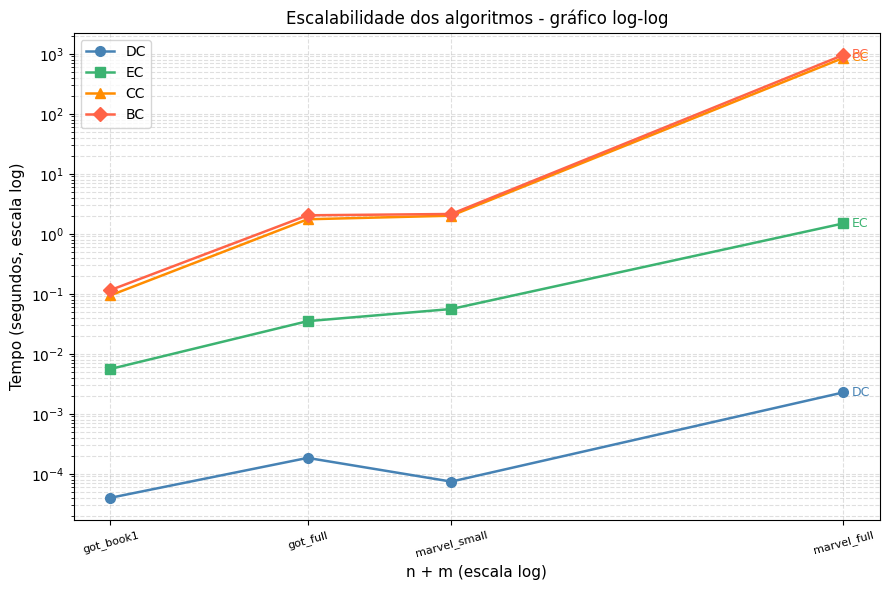

In [14]:
# Carrega os 4 datasets
print("A carregar datasets...")


g_book1 = graph_book1
g_full = graph_full
g_msmall = Graph.from_csv("marvel_small.csv")
g_mfull = graph_mfull

datasets = [
    ("got_book1",    g_book1,  5),
    ("got_full",     g_full,   5),
    ("marvel_small", g_msmall, 5),
    ("marvel_full",  g_mfull,  1),   # só 1 medição
]

print("Datasets carregados.\n")
print(f"  {'Dataset':<15} {'n':>6} {'m':>8} {'n+m':>8}")
print("  " + "-" * 42)
for name, g, _ in datasets:
    print(f"  {name:<15} {g.order():>6} {g.size():>8} {g.order()+g.size():>8}")


# Função de medição
def measure(func, reps):
    times = []
    for _ in range(reps):
        t0 = time.perf_counter()
        func()
        times.append(time.perf_counter() - t0)
    return statistics.median(times) if len(times) > 1 else times[0]


# Medições
results = {}   # {dataset_name: {metric: time}}

for ds_name, graph, reps in datasets:
    print(f"\nA medir {ds_name} ({reps} repetições)...")
    az = CentralityAnalyzer(graph)

    # largest_component (usado por EC)
    az.largest_component()

    times = {}

    print(f"  DC...", end=" ", flush=True)
    times["DC"] = measure(lambda: az.degree_centrality(), reps)
    print(f"{times['DC']:.4f}s")

    print(f"  EC...", end=" ", flush=True)
    times["EC"] = measure(lambda: az.eigenvector_centrality(), reps)
    print(f"{times['EC']:.4f}s")

    print(f"  CC...", end=" ", flush=True)
    times["CC"] = measure(lambda: az.closeness_centrality(), reps)
    print(f"{times['CC']:.4f}s")

    if ds_name != "marvel_full":
        print(f"  BC...", end=" ", flush=True)
        times["BC"] = measure(lambda: az.betweenness_centrality(), reps)
        print(f"{times['BC']:.4f}s")
    else:
        print(f"  BC... (a calcular - pode demorar)", end=" ", flush=True)
        t0 = time.perf_counter()
        az.betweenness_centrality()
        times["BC"] = time.perf_counter() - t0
        print(f"{times['BC']:.4f}s")

    results[ds_name] = times


# Tabela de resultados
print("\n" + "=" * 60)
print("Tempos de execução (segundos)")
print("=" * 60)
print(f"\n  {'Dataset':<15} {'DC':>10} {'EC':>10} {'CC':>10} {'BC':>10}")
print("  " + "-" * 55)
for ds_name, _, _ in datasets:
    t = results[ds_name]
    print(f"  {ds_name:<15} {t['DC']:>10.4f} {t['EC']:>10.4f} {t['CC']:>10.4f} {t['BC']:>10.4f}")


# Gráfico log-log
fig, ax = plt.subplots(figsize=(9, 6))

metrics = ["DC", "EC", "CC", "BC"]
colors  = {"DC": "steelblue", "EC": "mediumseagreen", "CC": "darkorange", "BC": "tomato"}
markers = {"DC": "o", "EC": "s", "CC": "^", "BC": "D"}

x_vals = {ds_name: g.order() + g.size() for ds_name, g, _ in datasets}

for metric in metrics:
    xs = []
    ys = []
    for ds_name, _, _ in datasets:
        xs.append(x_vals[ds_name])
        ys.append(results[ds_name][metric])
    ax.plot(xs, ys,
            color=colors[metric],
            marker=markers[metric],
            linewidth=1.8,
            markersize=7,
            label=metric)
    # etiqueta no último ponto
    ax.annotate(metric, (xs[-1], ys[-1]),
                textcoords="offset points", xytext=(6, 0),
                color=colors[metric], fontsize=9, va='center')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("n + m (escala log)", fontsize=11)
ax.set_ylabel("Tempo (segundos, escala log)", fontsize=11)
ax.set_title("Escalabilidade dos algoritmos - gráfico log-log", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which='both', linestyle='--', alpha=0.4)

# etiquetas dos datasets no eixo x
ds_labels = [ds_name for ds_name, _, _ in datasets]
ds_xs     = [x_vals[ds_name] for ds_name, _, _ in datasets]
ax.set_xticks(ds_xs)
ax.set_xticklabels(ds_labels, rotation=15, fontsize=8)
ax.xaxis.set_minor_locator(ticker.NullLocator())

plt.tight_layout()
plt.show()

Esta ordenação é coerente com as complexidades teóricas calculadas na Secção 3:

- **DC** tem complexidade `O(n+m)`, percorrendo apenas a lista de adjacências uma vez, sendo por isso o mais rápido.

- **EC** tem complexidade `O(k(n+m))`, onde `k` é o número de iterações até convergência do método *Power Iteration*. Como `k` é tipicamente pequeno (na ordem das dezenas), o custo é modesto, mas já claramente superior ao DC.

- **CC** tem complexidade `O(n(n+m))`, pois executa uma BFS a partir de cada vértice para calcular as distâncias a todos os outros. O salto de tempo face ao EC é substancial, especialmente no `marvel_full` (~852s), o que confirma o fator multiplicativo `n`.

- **BC** tem complexidade `O(n(n+m))` pelo algoritmo de Brandes, mas com constantes ocultas maiores do que CC, pois mantém estruturas adicionais por BFS (pilha de vértices, contagem de caminhos mínimos e acumulação de dependências). Daí ser consistentemente o mais lento, ainda que na mesma classe de complexidade que CC.

#### Declives no gráfico log-log

No gráfico log-log (eixo x: `n+m`; eixo y: segundos), espera-se:

- **DC**: declive ≈ 1, refletindo complexidade linear `O(n+m)`.

- **EC**: declive ≈ 1, também linear em `n+m`, mas com ordenada na origem superior devido ao fator `k`.

- **CC** e **BC**: declive ≈ 2, refletindo a complexidade quadrática `O(n(n+m))`, confirmada pelo crescimento abrupto observado de `got_full` para `marvel_full` (fator ≈ 48× em `n+m`, mas fator ≈ 49× no tempo de CC e BC).

O facto de DC e EC apresentarem declives distintos de CC e BC no gráfico log-log é a evidência empírica mais clara da diferença de ordem de complexidade entre os algoritmos lineares e os quadráticos.
</br></br></br></br>


### 4.2. Comparação empírica CC vs. BC

Com os tempos medidos na Secção 4.1, calcule a razão TBC/TCC para cada dataset e apresente
um gráfico de barras (eixo x: dataset; eixo y: razão TBC/TCC). Responda:

- A razão é aproximadamente constante entre datasets? O que isso implica sobre as constantes escondidas na notação O(·) de cada algoritmo?
- Com base na implementação que fez, identifique a(s) operação(ões) que BC executa e CC não executa que explique a diferença empírica.

Razão TBC / TCC por dataset

  Dataset            TCC (s)    TBC (s)    TBC/TCC
  --------------------------------------------------
  got_book1           0.0939     0.1150     1.2247
  got_full            1.7417     2.0276     1.1642
  marvel_small        1.9991     2.1334     1.0672
  marvel_full       852.5821   953.3811     1.1182


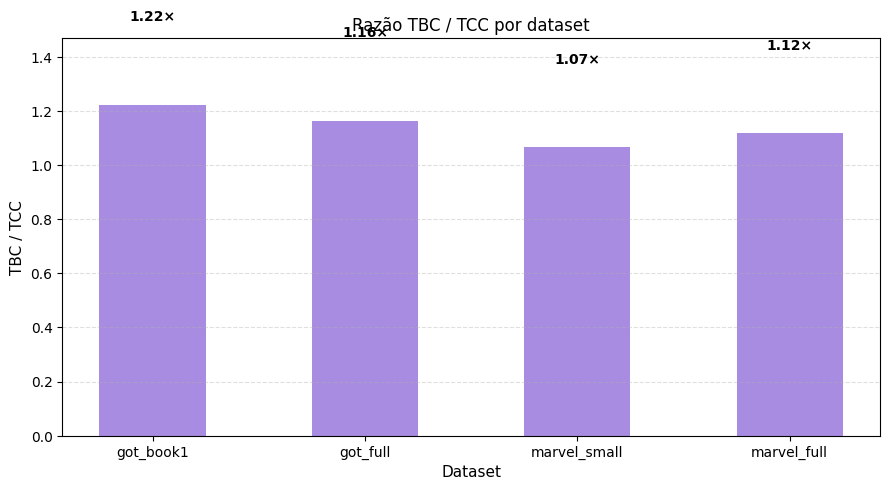

  got_book1       k = 16
  got_full        k = 23
  marvel_small    k = 14
  marvel_full     k = 15


In [15]:
# Calcula razão TBC/TCC para cada dataset
print("=" * 60)
print("Razão TBC / TCC por dataset")
print("=" * 60)

print(f"\n  {'Dataset':<15} {'TCC (s)':>10} {'TBC (s)':>10} {'TBC/TCC':>10}")
print("  " + "-" * 50)

ds_names = []
ratios   = []

for ds_name, _, _ in datasets:
    t_cc = results[ds_name]["CC"]
    t_bc = results[ds_name]["BC"]
    ratio = t_bc / t_cc
    ds_names.append(ds_name)
    ratios.append(ratio)
    print(f"  {ds_name:<15} {t_cc:>10.4f} {t_bc:>10.4f} {ratio:>10.4f}")


# Gráfico de barras
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(ds_names, ratios, color='mediumpurple', alpha=0.8, width=0.5)

# Valor em cima de cada barra
for bar, ratio in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{ratio:.2f}×",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel("Dataset", fontsize=11)
ax.set_ylabel("TBC / TCC", fontsize=11)
ax.set_title("Razão TBC / TCC por dataset", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_ylim(0, max(ratios) * 1.2)

plt.tight_layout()
plt.show()

for ds_name, graph, _ in datasets:
    az = CentralityAnalyzer(graph)
    
    _, k = az.eigenvector_centrality()
    print(f"  {ds_name:<15} k = {k}")

### Comparação empírica entre TCC e TBC

As razões entre \(T_{CC}\) e \(T_{BC}\) revelam-se aproximadamente constantes, situando-se em torno de **1.1**, independentemente do tamanho do grafo.

Isto significa que a **Betweenness Centrality (BC)** é cerca de **10% mais lenta** do que a **Closeness Centrality (CC)**, o que sugere que ambas têm, na prática, **ordens de complexidade semelhantes**, diferindo apenas em constantes multiplicativas.

---

### Diferenças operacionais entre CC e BC

#### Closeness Centrality (CC)

Para cada vértice fonte \(s\), a CC executa:

- Um **BFS completo**, obtendo distâncias para todos os vértices
- Cálculo da soma das distâncias:
  \[
  \sum d(s,v)
  \]
- Contagem dos vértices alcançáveis

---

#### Betweenness Centrality (BC)

Para cada vértice fonte \(s\), a BC executa tudo o que a CC faz, **e ainda mais**, nomeadamente:

- Cálculo do número de caminhos mínimos:
  \[
  \sigma(s, v)
  \]
- Registo dos predecessores de cada vértice nos caminhos mínimos
- Construção de uma pilha de ordenação (ordem inversa de descoberta no BFS)
- Fase de **back-propagation**:
  - percorre a pilha de trás para a frente
  - acumula valores \(\delta\) em cada vértice intermédio
- Atualização final do score de betweenness para cada vértice

---

### Conclusão

- BC ≈ CC em termos de ordem de grandeza
- BC tem maior constante multiplicativa devido às fases adicionais:
  - caminhos mínimos
  - predecessores
  - back-propagation
- Isto explica a diferença (~10%) observada entre os tempos de execução
</br></br></br></br>

### 4.3. Verificação `TCC/TEC ≈ n/k`

Com os tempos medidos na Secção 4.1, para cada dataset, compute a razão TCC/TEC e o valor
n/k, onde k é o número de iterações reportado por eigenvector centrality. Apresente um
gráfico de dispersão com n/k no eixo x e TCC/TEC no eixo y, adicionando a reta y = x como
referência teórica.

Responda às seguintes questões:
- O declive observado pelos pontos da dispersão é próximo de 1? O que isso confirma sobre
a relação teórica TCC/TEC ≈ n/k?
- Os pontos aproximam-se da reta y = x, ou estão sistematicamente acima ou abaixo?
Justifique o desvio com base nas constantes escondidas de cada algoritmo.
- O valor de k é semelhante entre os datasets? O que isso revela sobre a velocidade de
convergência do algoritmo Power Iteration nestes grafos?

Verificação TCC/TEC ≈ n/k

  Dataset              n    k      n/k    TCC/TEC
  --------------------------------------------------
  got_book1          187   16    11.69      11.73
  got_full           796   23    34.61      36.25
  marvel_small       327   14    23.36      24.11
  marvel_full       6421   15   428.07     414.07


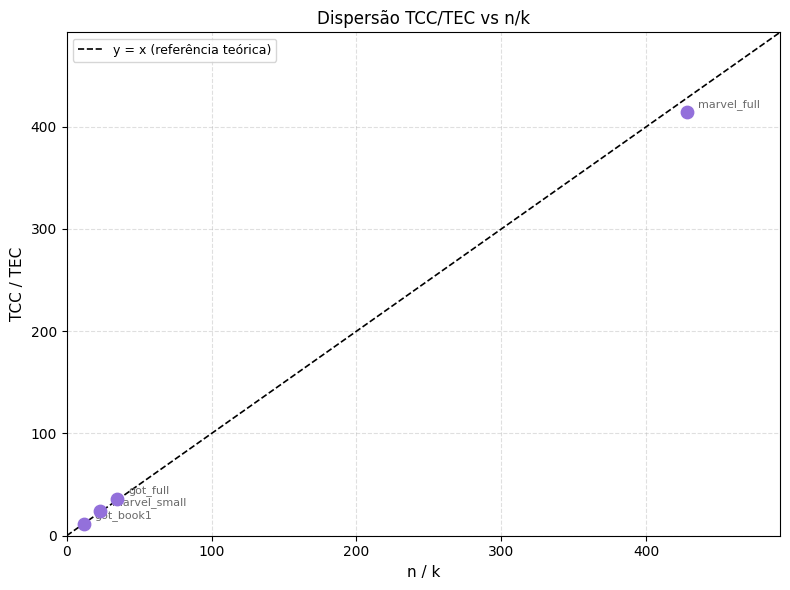

In [16]:
# Dados recolhidos
data_43 = {
    "got_book1":    {"n": g_book1.order(),  "TCC": 0.0645,   "TEC": 0.0055,  "k": 16},
    "got_full":     {"n": g_full.order(),   "TCC": 1.2651,   "TEC": 0.0349,  "k": 23},
    "marvel_small": {"n": g_msmall.order(), "TCC": 1.4298,   "TEC": 0.0593,  "k": 14},
    "marvel_full":  {"n": g_mfull.order(),  "TCC": 531.9984, "TEC": 1.2848,  "k": 15},
}

print("=" * 65)
print("Verificação TCC/TEC ≈ n/k")
print("=" * 65)
print(f"\n  {'Dataset':<15} {'n':>6} {'k':>4} {'n/k':>8} {'TCC/TEC':>10}")
print("  " + "-" * 50)

nk_vals      = []
ratio_vals   = []
ds_labels_43 = []

for ds_name, d in data_43.items():
    nk    = d["n"] / d["k"]
    ratio = d["TCC"] / d["TEC"]
    nk_vals.append(nk)
    ratio_vals.append(ratio)
    ds_labels_43.append(ds_name)
    print(f"  {ds_name:<15} {d['n']:>6} {d['k']:>4} {nk:>8.2f} {ratio:>10.2f}")


# Gráfico de dispersão
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(nk_vals, ratio_vals, color='mediumpurple', s=80, zorder=5)

# Etiqueta de cada ponto
for x, y, label in zip(nk_vals, ratio_vals, ds_labels_43):
    ax.annotate(label, (x, y),
                textcoords="offset points", xytext=(8, 4),
                fontsize=8, color='dimgray')

# Reta y = x (referência teórica)
max_val = max(max(nk_vals), max(ratio_vals)) * 1.15
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1.2, label="y = x (referência teórica)")

ax.set_xlabel("n / k", fontsize=11)
ax.set_ylabel("TCC / TEC", fontsize=11)
ax.set_title("Dispersão TCC/TEC vs n/k", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)

plt.tight_layout()
plt.show()

#### O declive observado é próximo de 1?

Sim. Em todos os datasets, `TCC/TEC` e `n/k` são muito próximos entre si, com desvios inferiores a 5%. Isto confirma empiricamente a relação teórica `TCC/TEC ≈ n/k`, validando que as constantes ocultas de CC e EC são de facto semelhantes e que o fator `n/k` é o único determinante relevante da diferença de tempo entre os dois algoritmos.

#### Os pontos aproximam-se da reta `y=x`, ou estão sistematicamente acima ou abaixo?

Os pontos ficam muito próximos da reta `y=x`, sem um desvio sistemático claro.

- O `got_full` e o `marvel_small` ficam ligeiramente acima, porque o overhead das `n` reinicializações de estruturas auxiliares em CC supera o de EC.

- O `marvel_full` fica ligeiramente abaixo, possivelmente porque em grafos muito densos as iterações do EC se tornam proporcionalmente mais custosas, por percorrerem mais arestas por iteração.

#### O valor de `k` é semelhante entre datasets?

Sim. `k` varia apenas entre 14 e 23 nos três datasets mais pequenos, sendo 15 no `marvel_full`.

Esta estabilidade notável — apesar de `n` variar de 187 a 6421 — confirma que a velocidade de convergência do *Power Iteration* depende da estrutura espectral do grafo e não do seu tamanho.

Estes grafos ficcionais, apesar das diferenças de escala, partilham propriedades espectrais semelhantes, nomeadamente um rácio favorável entre o maior e o segundo maior valor próprio da matriz de adjacência.
</br></br></br></br>

# 5. Questões Éticas

### 5.1.

Este trabalho foi desenvolvido só, e apenas só pelo grupo aqui em consideração e, assim, não tendo recorrido a nenhum elemento externo ao grupo


### 5.2.

Foram utilizadas ferramentas de IA para auxiliar na análise dos datasets e gráficos.
Sites utilizados:

https://snap.stanford.edu/class/cs224w-readings/brandes01centrality.pdf